# ***A Retrieval-Augmented Legal Question Answering System for the Philippine Data Privacy Act Using Falcon-7B***

***CSS181-3: AI Specialization***

**Natural Language Processing Project**

**Group Members:**
*   Kyle Hendrik L. Lim
*   Gabriel Christian Tan





# ***Section 1: Introduction***

**Large Language Models (LLMs)** have demonstrated strong performance in question answering and text understanding tasks across multiple domains. However, when applied to legal and policy documents, these models often provide seemingly legitimate but incorrect answers and struggle to accurately gauge their own level of certainty [1]. This limitation poses a significant risk in legal contexts, where inaccuracies may lead to misinterpretation of laws, incorrect compliance decisions, or legal liability, and highlights the need for approaches that ground model responses in authoritative sources.

To address this issue, **Retrieval-Augmented Generation (RAG)** has emerged as a promising approach. By grounding model responses in an external knowledge source, RAG systems aim to reduce hallucinations and improve factual consistency. Despite its growing adoption, the effectiveness of RAG in minimizing hallucinations for Philippine legal documents, such as the Data Privacy Act of 2012 **(Republic Act No. 10173)**, remains underexplored.

This project investigates the application of RAG-based NLP techniques to a legal policy document, with a specific focus on hallucination reduction and contextual accuracy.

## **1.1 Problem Overiew**


---

Legal texts are characterized by structured sections, formal language, and precise terminology. General-purpose LLMs, when queried without document grounding, may fabricate explanations, misattribute penalties, or reference non-existent provisions. Even instruction-tuned models can generate misleading outputs when the required information is not explicitly present in their internal knowledge.

For laws such as the **Data Privacy Act of 2012**, where correct interpretation is essential, hallucinated responses undermine trust and usability. There is a need for systems that can accurately retrieve and reference specific sections of the law while minimizing unsupported claims.

## **1.2 Task Definition**


---


The task addressed in this project is legal question answering over a collection of authoritative documents related to the Data Privacy Act of 2012 using a Retrieval-Augmented Generation pipeline. Given a natural language query (e.g., “What section describes penalties for unauthorized access?”), the system must:

1. Retrieve the most relevant portions of the **Data Privacy Act** and its related implementing rules
2. Generate an answer grounded strictly in the retrieved text
3. Avoid introducing information not supported by the document


The task emphasizes faithfulness to source material rather than linguistic creativity.

## **1.3 Dataset Summary**


---


The dataset used in this study consists of multiple official and publicly available PDF documents related to the Republic Act No. 10173, also known as the Data Privacy Act of 2012. These documents include the primary text of the Act as well as its Implementing Rules and Regulations (IRR), issued and maintained by authoritative Philippine government institutions.

Collectively, the documents cover the legal definitions, rights of data subjects, obligations of personal information controllers and processors, enforcement mechanisms, penalties, and procedural guidelines associated with data privacy compliance in the Philippines. While the core legal provisions remain consistent across documents, variations exist in document length, structure, and explanatory detail.

The dataset is characterized by the following properties:

- Publicly available and authoritative

- Legally binding or regulatory in nature

- Structured into chapters and sections, but presented in unstructured PDF format

- Written in formal legal language

These characteristics make the dataset suitable for evaluating retrieval accuracy, contextual grounding, and hallucination behavior in legal-domain NLP systems.

## **1.4 Project Objectives**


---

The primary objectives of this project are:

1. To design a Retrieval-Augmented Generation pipeline for legal document question answering

2. To evaluate multiple open-source LLMs under identical RAG conditions

3. To measure hallucination behavior using defined qualitative metrics

4. To apply parameter-efficient fine-tuning techniques to reduce hallucinations

5. To demonstrate improved factual grounding in responses to legal queries

The project prioritizes accuracy, reproducibility, and interpretability over raw model size or generative fluency.

## **1.5 Relevance**


---


This study is relevant to both academic research and practical applications. From an academic perspective, it contributes to ongoing discussions on hallucination mitigation and evaluation in legal NLP. From a practical standpoint, the findings may inform the development of AI-assisted legal information systems, compliance tools, and policy analysis platforms.

By focusing on a Philippine legal document, this work also addresses a gap in region-specific NLP research, which is often dominated by U.S. or EU legal corpora. The project demonstrates how open-source models and modest computational resources can be leveraged responsibly for legal-domain AI applications.





# ***Section 2: Dataset Description***

This study uses a collection of official legal documents related to **Republic Act No. 10173 — the Data Privacy Act of 2012**, which governs the collection, processing, storage, and protection of personal data in the Philippines. These documents collectively serve as the authoritative knowledge source for the retrieval-augmented generation (RAG) system evaluated in this project.

Rather than relying on a single file, the dataset consists of multiple publicly issued PDF documents that contain the statutory text of the Act and its corresponding implementing rules and amendments. All documents originate from official government bodies and present consistent legal content with minor variations in length, formatting, and supplementary material.

## **2.1 Data Source and Accessibility**


---


The datasets were obtained from official and publicly accessible Philippine government sources, including publications from the **National Privacy Commission** (NPC) and other government-hosted repositories. As statutory legal documents and implementing regulations, these materials are in the public domain and may be freely accessed for research and educational purposes.

All datasets are provided in **Portable Document Format (PDF)** and represent legally authoritative texts, including the full provisions of the **Data Privacy Act of 2012**, its **Implementing Rules and Regulations (IRR)**, and subsequent amendments. While some documents differ in pagination and introductory content, the substantive legal sections remain consistent across sources.

## **2.2 Document Characteristics**


---


The Data Privacy Act of 2012 and its associated implementing rules are structured legal documents composed of clearly defined chapters and numbered sections. These sections specify data subject rights, obligations of personal information controllers and processors, enforcement mechanisms, and penalties for violations.

Key characteristics of the datasets include:

- Formal legal language

- Section-based structure with explicit numbering

- Dense, non-conversational text

- Cross-references between sections and provisions

These characteristics present challenges for language models, particularly in maintaining contextual accuracy, resolving cross-references, and avoiding unsupported inferences during answer generation.

## **2.3 Data Scope and Size**


---


The dataset consists of five related legal PDF documents covering the same legislative framework. Although the documents vary in length and formatting, they collectively represent a focused and coherent legal corpus centered on a single law.

Compared to large-scale legal datasets, the overall corpus remains relatively small. However, it contains sufficient semantic and structural complexity to evaluate hallucination behavior, retrieval accuracy, and contextual grounding in legal question-answering tasks. The constrained scope enables controlled experimentation while ensuring that all generated outputs can be verified against authoritative source material.

## **2.4 Relevance to the Task**


---


The Data Privacy Act of 2012 and its implementing rules were selected due to their:

- Clear legal structure suitable for retrieval-based methods

- Practical relevance to contemporary data governance, privacy, and cybersecurity concerns

- Suitability for evaluating hallucination mitigation in policy-oriented NLP tasks

By focusing on a small set of closely related, authoritative legal documents, this project isolates hallucination behavior while allowing systematic evaluation of how effectively retrieval-augmented generation constrains model outputs in the legal domain.

# ***Section 3: Requirements***

This section describes the software environment and libraries used to implement the Retrieval-Augmented Generation (RAG) pipeline and conduct the baseline evaluation. All libraries included are actively used within the notebook and support key stages of the workflow, including document processing, text chunking, embedding generation, retrieval, and large language model inference.

## **3.1 Core Python Utilities**


---


Standard Python libraries are used for file handling, data serialization, and text preprocessing:

- **os** – Handles directory traversal and file path management for loading datasets.

- **re** – Supports basic text cleaning and pattern matching.

- **json** – Used to save and reload randomly sampled dataset sections to ensure reproducibility across sessions.

- **typing** (List, Dict) – Improves code readability and type clarity.

## **3.2 Numerical and Data Handling**


---


These libraries support vector operations and structured result storage:

- **NumPy** – Used for numerical operations and handling embedding vectors.

- **Pandas** – Used to store and compare prompt outputs, evaluation results, and metadata in tabular form.

## **3.3 PDF Processing**


---


- **PyMuPDF** (fitz) – Extracts text from PDF files page by page. This library is used to parse all legal documents included in the dataset and preserve section-level context.

## **3.4 Text Chunking and Document Representation**


---


- **LangChain Document schema** – Represents extracted text along with metadata such as source file and section identifiers.

- **RecursiveCharacterTextSplitter** – Splits long legal sections into overlapping chunks while preserving semantic continuity, which is critical for effective retrieval in RAG systems.

## **3.5 Embeddings and Vector Retrieval**


---


These libraries form the core of the retrieval component:

- **Sentence-Transformers** – Generates dense vector embeddings for legal text segments.

- **FAISS** – Indexes embeddings and performs efficient similarity search to retrieve relevant document chunks during inference.

## **3.6 Large Language Model Framework**


---


These libraries are used to load and run open-source LLMs locally:

- **PyTorch** – Provides the backend for model execution and GPU acceleration.

- **Hugging Face Transformers** – Loads pretrained causal language models and tokenizers for text generation.

## **3.7 Progress Tracking**


---


- **tqdm** – Displays progress bars during long-running processes such as PDF parsing, embedding generation, and batch inference, improving transparency during experimentation.n

## **3.8 Installing Required Packages**


---


Before running any code in this project, all necessary Python packages must be installed. This ensures the notebook can execute properly and all dependencies for PDF processing, embeddings, and model evaluation are available.

In [ ]:
# Torch:
!pip install -q torch

# Core NLP stack
!pip install -q sentence-transformers transformers faiss-cpu PyMuPDF tqdm

# LangChain (modern structure)
!pip install -q langchain langchain-community

# OpenAI SDK
!pip install -q openai

!pip install -q bitsandbytes
!pip install -q accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 6.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.4 MB/s eta 0:00:00


## **3.9 Consolidated Import Cell**


---


The following code cell consolidates all required imports used throughout the notebook. Subsequent sections reference this centralized import setup to maintain clarity and avoid redundancy

In [ ]:
# Core utilities
import os
import sys
import re
import numpy as np
import pandas as pd
import random
import json
from tqdm import tqdm

# Torch
import torch

# Sentence embeddings
from sentence_transformers import SentenceTransformer

# Vector search
import faiss
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings

# LangChain core (modern API)
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import CharacterTextSplitter

# OpenAI SDK
from openai import OpenAI

print("✅ All imports successful. LangChain modern API loaded.")

✅ All imports successful. LangChain modern API loaded.


# ***Section 4: System Architecture (RAG Pipeline)***

## **4.1 Environment Setup and Dataset Access**


---


Before accessing the dataset, Google Drive is mounted to the Colab environment. This allows the project to directly reference documents stored in a shared Drive directory, ensuring that all group members can execute the notebook without repeatedly uploading files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


To standardize dataset access across different users and sessions, the base project directory and dataset directory are explicitly defined. The dataset directory contains all source documents used in the study, allowing the pipeline to scale beyond a single PDF file.

In [ ]:
BASE_DIR = "/content/drive/MyDrive/Mapua /3rd Year Term 2/CSS181-3/NLP_Project"
DATA_DIR = f"{BASE_DIR}/data"

After mounting Google Drive, the project verifies the existence of the dataset directory and lists its contents. This step confirms that the required documents are accessible and helps prevent runtime errors caused by incorrect paths or missing files.

In [ ]:
print(f"Listing contents of dataset directory: {DATA_DIR}")
try:
    for item in os.listdir(DATA_DIR):
        print(item)
except FileNotFoundError:
    print(f"Error: Directory not found at {DATA_DIR}. Please check the path.")

Listing contents of dataset directory: /content/drive/MyDrive/Mapua /3rd Year Term 2/CSS181-3/NLP_Project/data
RA-10173-Data-Privacy-Act-of-2012.pdf
10173-IRR-25-Aug-2016.pdf
philippines-dpa-of-2012.pdf
updated-draft-July-12-2016.pdf
IRR_RA-10173-as-amended.pdf
baseline_section_samples_v1.json


An assertion check is used to ensure that the dataset directory exists and contains at least one document. This provides an early failure signal if the dataset has not been properly prepared.

In [ ]:
assert os.path.exists(DATA_DIR), "❌ Dataset directory not found."
assert len(os.listdir(DATA_DIR)) > 0, "❌ Dataset directory is empty."
print("✅ Dataset directory verified.")

✅ Dataset directory verified.


The project relies on the PyPDF2 library for reading and processing the PDF document. The environment confirms that the required dependency is already installed.

In [ ]:
pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.8 MB/s eta 0:00:00


Finally, the PDF document is loaded using PyPDF2, and the total number of pages is printed. This serves as a sanity check to confirm successful loading of the dataset.

In [ ]:
from PyPDF2 import PdfReader

pdf_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".pdf")]

assert len(pdf_files) > 0, "No PDF files found in the data directory."

print(f"Found {len(pdf_files)} PDF file(s):")
for pdf in pdf_files:
    print("-", pdf)

readers = {}
total_pages = 0

for pdf in pdf_files:
    pdf_path = os.path.join(DATA_DIR, pdf)
    reader = PdfReader(pdf_path)
    readers[pdf] = reader
    num_pages = len(reader.pages)
    total_pages += num_pages
    print(f"Loaded {pdf} | Pages: {num_pages}")

print(f"\n Total pages across all documents: {total_pages}")

Found 5 PDF file(s):
- RA-10173-Data-Privacy-Act-of-2012.pdf
- 10173-IRR-25-Aug-2016.pdf
- philippines-dpa-of-2012.pdf
- updated-draft-July-12-2016.pdf
- IRR_RA-10173-as-amended.pdf
Loaded RA-10173-Data-Privacy-Act-of-2012.pdf | Pages: 15
Loaded 10173-IRR-25-Aug-2016.pdf | Pages: 49
Loaded philippines-dpa-of-2012.pdf | Pages: 26
Loaded updated-draft-July-12-2016.pdf | Pages: 42
Loaded IRR_RA-10173-as-amended.pdf | Pages: 29

 Total pages across all documents: 161


## **4.2 PDF Text Extraction**


---


The goal of this subsection is to convert the PDF documents into raw text while preserving the legal structure (Acts, Sections, Subsections). Proper extraction is critical because the retrieval-augmented generation (RAG) system will rely on the extracted text to answer prompts accurately.

**Challenges**

* Legal PDFs often contain headers, footers, and page numbers.

* Some sections may be split across pages.

* Accurate extraction is necessary to avoid hallucinations when models are queried.

### **4.2.1 Import Required Libraries**

We will use PyPDF2 to read the PDF content. PyPDF2 provides tools to access the text content of each page, enabling us to extract the full legal text from multiple documents for further cleaning and processing.

In [ ]:
from PyPDF2 import PdfReader

In order to read and process the PDF document, we import the PyPDF2 library. This library provides tools to access the text content of each page, enabling us to extract the full legal text into a Python string that can be further cleaned and processed.

### **4.2.2 Load the PDF and Extract Pages**

In [ ]:
DATA_DIR = f"{BASE_DIR}/data"
pdf_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith('.pdf')]

# Storage for extracted text
documents = []

for pdf_file in pdf_files:
    pdf_path = os.path.join(DATA_DIR, pdf_file)
    reader = PdfReader(pdf_path)
    for i, page in enumerate(reader.pages):
        page_text = page.extract_text()
        if page_text:
            documents.append({
                "source": pdf_file,
                "page_number": i+1,
                "text": page_text
            })
        else:
            print(f"Warning: {pdf_file} Page {i+1} has no text")

print(f"Text extraction complete. {len(documents)} pages extracted from {len(pdf_files)} PDFs.")

Text extraction complete. 161 pages extracted from 5 PDFs.


Here, we load all PDFs from the /data folder` and iterate over each page to extract the text content. The extracted text for each document is stored separately along with its filename and page number. Pages without text are skipped, with a warning printed. This approach ensures that every document is captured individually while preserving page order, which is crucial for accurate retrieval in the RAG system.

**Sanity Check**

Print first 1000 characters for verification

In [ ]:
# Print first 1000 characters of the first page from the first document
if documents:
    print(documents[0]['text'][:1000])
else:
    print("No documents were extracted.")

gov.ph
http://www.gov.ph/2012/08/15/republic-act-no-10173/
Republic of the Philippines
Congress of the Philippines
Metro Manila
Fifteenth Congress
Second Regular Session
Begun and held in Metro Manila, on Monday, the twenty-fifth day of July, two thousand eleven.
[REPUBLIC ACT NO. 10173]
AN ACT PROTECTING INDIVIDUAL PERSONAL INFORMATION IN INFORMATION AND
COMMUNICATIONS SYSTEMS IN THE GOVERNMENT AND THE PRIVATE SECTOR,
CREATING FOR THIS PURPOSE A NATIONAL PRIVACY COMMISSION, AND FOR OTHER
PURPOSES
Be it enacted, by the Senate and House of Representatives of the Philippines in Congress
assembled:
CHAPTER I
GENERAL PROVISIONS
SECTION 1
. Short Title. – 
This Act shall be known as the
 
“Data Privacy Act of 2012″.
SEC. 2. 
Declaration of Policy. – 
It is the policy of the State to protect the fundamental human right of
privacy, of communication while ensuring free flow of information to promote innovation and growth.
The State recognizes the vital role of information and communications te

After extraction, it is important to inspect a portion of the raw text to verify that the process worked correctly. Printing the first page of the first document provides a quick check for correct extraction and allows us to identify potential formatting issues, headers, or footers that may need to be removed in later preprocessing steps.

### **4.2.3 Page-wise Storage**

In [ ]:
# Store each page separately in a list
page_texts = [page.extract_text() for page in reader.pages]

print(page_texts[0][:500])

 
 
Republic of the Philippines  
NATIONAL PRIVACY COMMISSION  
 
 
IMPLEMENTING RULES AND REGULATIONS OF REPUBLIC ACT NO. 10173, 
ALSO KNOWN AS THE “DATA PRIVACY ACT OF 2012”  
 
Pursuant to the mandate of the National Privacy Commission to administer and implement the 
provisions of the Data Privacy Act of 2012, and to monitor and ensure compliance of the country with 
international standards set for data protection, the following r ules and regulations are hereby 
promulgated to effectively i


While combining the text of an entire document can be useful, storing text page-wise improves retrieval accuracy and makes hallucination analysis easier. Each page retains its original mapping to the source document and page number.

### **4.2.4 Next Steps**

Once text extraction is complete for all documents, the next stage will focus on cleaning and normalizing the text to remove noise, headers, and other artifacts. After cleaning, the text will be divided into chunks appropriate for embedding and retrieval. Metadata such as page numbers, source filenames, section numbers, and chunk IDs will also be added to facilitate precise retrieval and evaluation.

## **4.3 Text Cleaning and Normalization**


---


After extracting the raw text from the PDF documents, it is essential to clean and normalize the content before it can be used for retrieval and question-answering. Legal documents often contain page headers, footers, inconsistent whitespace, line breaks, and other formatting artifacts that could negatively affect model performance. Normalizing the text ensures that each section and subsection is represented consistently and that embeddings used in the RAG system are based on accurate, meaningful content.

The cleaning process is applied individually to each page of each document, so that we can preserve document and page metadata while preparing the text for chunking.

### **4.3.1 Remove Extra Whitespace and Line Breaks**

In [ ]:
# Create a new list to store cleaned texts
cleaned_documents = []

for doc in documents:
    text = doc['text']

    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove known headers/footers (example pattern)
    text = re.sub(r'Republic Act No\. 10173.*?\d+', '', text, flags=re.IGNORECASE)

    # Store back with original metadata
    cleaned_documents.append({
        "source": doc["source"],
        "page_number": doc["page_number"],
        "text": text
    })

print(f"Basic whitespace and header/footer cleaning complete for {len(cleaned_documents)} pages.")


Basic whitespace and header/footer cleaning complete for 161 pages.


We normalize whitespace by collapsing multiple spaces, tabs, and line breaks into a single space. Any known headers or footers are removed using regular expressions. These steps prevent repeated non-informative text from affecting embeddings or retrieval performance. This cleaning is applied to each page of every document.

### **4.3.2 Normalize Legal Sections**

In [ ]:
for doc in cleaned_documents:
    text = doc['text']
    # Normalize section references
    text = re.sub(r'Sec\. (\d+)', r'Section \1', text)
    text = re.sub(r'Sections (\d+)-(\d+)', r'Section \1 to \2', text)
    doc['text'] = text

print("Legal section normalization complete.")

Legal section normalization complete.


Legal documents often use inconsistent ways to refer to sections, such as “Sec. 1” or “Sections 2-4.” Normalizing these references ensures the RAG system can identify sections consistently. Standardizing section formatting improves chunking and the model’s ability to locate relevant passages during retrieval.

### **4.3.3 Lowercasing / Encoding Normalization**

In [ ]:
for doc in cleaned_documents:
    text = doc['text']
    # Optional: lowercase for embeddings
    text = text.lower()
    # Remove non-standard characters
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    doc['text'] = text

print("Text normalization complete.")

Text normalization complete.


Depending on the embeddings and model used, lowercasing can standardize token representation, ensuring that similar words are treated consistently. Non-standard or special characters introduced during PDF extraction are removed to prevent encoding issues. This guarantees that the text is in a uniform format suitable for downstream chunking and embedding.

**Sanity Check**

Print a sample of cleaned text for verification

In [ ]:
# Print first 1000 characters of the first page in cleaned documents
if cleaned_documents:
    print(cleaned_documents[0]['text'][:1000])
else:
    print("No cleaned documents available.")

gov.ph http://www.gov.ph/2012/08/15/republic-act-no-10173/ republic of the philippines congress of the philippines metro manila fifteenth congress second regular session begun and held in metro manila, on monday, the twenty-fifth day of july, two thousand eleven. [ . short title.   this act shall be known as the  data privacy act of 2012 . sec. 2. declaration of policy.   it is the policy of the state to protect the fundamental human right of privacy, of communication while ensuring free flow of information to promote innovation and growth. the state recognizes the vital role of information and communications technology in nation-building and its inherent obligation to ensure that personal information in information and communications systems in the government and in the private sector are secured and protected. sec. 3. definition of terms.   whenever used in this act, the following terms shall have the respective meanings hereafter set forth: (a) commission shall refer to the national

A quick visual inspection of the cleaned text is critical to verify that preprocessing did not inadvertently remove essential legal content. Printing a sample page from the first document allows us to confirm that sections, subsections, and key terms remain intact while extraneous formatting artifacts have been removed.

### **4.3.4 Next Steps**

After the text has been cleaned and normalized, the documents are ready for chunking, where each page will be divided into smaller, manageable pieces for embedding and retrieval. Metadata such as page number, source document, section numbers, and chunk IDs will be added to facilitate precise retrieval and evaluation during model testing.

## **4.4 Document Chunking and Metadata Construction**


---


After cleaning and normalizing the texts from multiple PDF documents, the next step is to divide them into smaller, meaningful chunks. Chunking is critical for retrieval-augmented generation (RAG) systems because it allows the model to access only relevant sections of each document, improving answer accuracy and reducing hallucination. Each chunk will also include metadata such as page numbers, section numbers, and chunk IDs to support traceability and proper citation in answers.

All subsequent steps are applied to each document individually, and chunks are combined into a single dataset while preserving document-level metadata.

### **4.4.1 Define Chunking Function**

In [ ]:
def chunk_text(text, chunk_size=500, overlap=50):
    """
    Splits text into overlapping chunks for RAG processing.

    Args:
        text (str): The cleaned text to be chunked.
        chunk_size (int): Approximate number of words per chunk.
        overlap (int): Number of words to overlap between chunks.

    Returns:
        List of string chunks.
    """
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = start + chunk_size
        chunk = " ".join(words[start:end])
        chunks.append(chunk)
        start = end - overlap  # overlap words for context
    return chunks

This function splits the text into chunks of approximately chunk_size words, with a small overlap between consecutive chunks to preserve context. Overlapping ensures that important information spanning two chunks is not lost, which is especially important in legal documents. By using word-based chunking rather than character-based, we maintain semantic integrity and improve retrieval quality. This function will later be applied to each cleaned page of each document.

### **4.4.2 Apply Chunking**

In [ ]:
# List to store all chunks and metadata
all_chunks = []

chunk_id_counter = 0

for doc in cleaned_documents:
    text = doc['text']
    source = doc['source']
    page_number = doc['page_number']

    # Generate chunks for this page
    chunks = chunk_text(text, chunk_size=500, overlap=50)

    # Append chunks with metadata
    for chunk in chunks:
        all_chunks.append({
            "chunk_id": chunk_id_counter,
            "text": chunk,
            "source": source,
            "page_number": page_number
        })
        chunk_id_counter += 1

print(f"Total chunks created across all documents: {len(all_chunks)}")
print("Sample chunk:\n", all_chunks[0]['text'][:500])

Total chunks created across all documents: 198
Sample chunk:
 gov.ph http://www.gov.ph/2012/08/15/republic-act-no-10173/ republic of the philippines congress of the philippines metro manila fifteenth congress second regular session begun and held in metro manila, on monday, the twenty-fifth day of july, two thousand eleven. [ . short title. this act shall be known as the data privacy act of 2012 . sec. 2. declaration of policy. it is the policy of the state to protect the fundamental human right of privacy, of communication while ensuring free flow of info


The chunking function is applied to every page of every document. Each chunk is stored in a dictionary with a unique chunk_id, the source document filename, and the original page number. This preserves traceability and allows the RAG system to correctly attribute answers to the original document. Printing a sample chunk and total count ensures the process executed correctly.

### **4.4.3 Metadata Construction**

In [ ]:
# Convert the list of chunks into a DataFrame
df_chunks = pd.DataFrame(all_chunks)

print("Metadata construction complete")
df_chunks.head()

Metadata construction complete


,chunk_id,text,source,page_number
0,0,gov.ph http://www.gov.ph/2012/08/15/republic-a...,RA-10173-Data-Privacy-Act-of-2012.pdf,1
1,1,computer system or other similar device by or ...,RA-10173-Data-Privacy-Act-of-2012.pdf,2
2,2,branch or agency in the philippines subject to...,RA-10173-Data-Privacy-Act-of-2012.pdf,2
3,3,(a) information about any individual who is or...,RA-10173-Data-Privacy-Act-of-2012.pdf,3
4,4,act done or practice engaged in and outside of...,RA-10173-Data-Privacy-Act-of-2012.pdf,3


Converting all chunks to a Pandas DataFrame allows for easier manipulation, indexing, and future embedding generation. Metadata includes the chunk ID, source document, and page number. Section numbers or other document-specific markers can be added later if parsed from the text.

### **4.4.4 Save Chunks for Reproducibility**

In [ ]:
# Save all chunks to CSV for reproducibility
df_chunks.to_csv(f"{BASE_DIR}/all_documents_chunks.csv", index=False)
print("Chunks saved to CSV")

Chunks saved to CSV


Saving the chunked data to a CSV ensures reproducibility and allows collaborators to access the same dataset without re-running extraction and cleaning. The filename all_documents_chunks.csv reflects that multiple PDFs were processed. This CSV can be used for embedding generation, retrieval, and evaluation in the next stages.

### **4.4.5 Next Steps**

After chunking and metadata construction, the dataset is fully prepared for the embedding and retrieval steps of the RAG pipeline. Each chunk is self-contained, semantically coherent, and accompanied by metadata for traceability. The next stage will focus on generating embeddings using a Transformer-based model, indexing, and setting up the retrieval system to evaluate the performance of the three candidate models (Falcon-7B, Hermes-7B, Qwen-7B-Instruct) in answering prompt queries accurately.

# ***Section 5: Model Selection & Baseline Evaluation***


## **5.1 Candidate Model Overview**


---


In this project, we aim to evaluate and compare multiple large language models (LLMs) for their ability to accurately retrieve and generate information from legal documents, specifically the Republic Act 10173 — Data Privacy Act of 2012. Our selection criteria prioritize open-source models that are freely available, capable of handling legal language, and of a manageable size (~7B parameters) to ensure feasibility within a Google Colab environment.

**Generative Models for Baseline Evaluation**

The models chosen for baseline evaluation are:

1. Falcon-7B **[2]**

    * Falcon-7B is a high-performing, open-source LLM developed by the Technology Innovation Institute.

    * It is well-regarded for instruction-following tasks and demonstrates strong general reasoning capabilities.

    * Its size and performance balance make it suitable for a local environment like Google Colab without requiring excessive resources.

2. Hermes-7B (NousResearch/Nous-Hermes-llama-2-7b) **[3]**

    * Hermes-7B is selected as an alternative to LLaMA-based models to avoid overlap with prior work.

    * It supports instruction tuning and demonstrates strong contextual understanding, making it a viable candidate for legal prompt-answering.

3. Qwen-7B (Qwen/Qwen2.5-7B-Instruct) **[4]**

    * Qwen-7B-Instruct is an open-source model optimized for instruction following and fine-tuning.

    * It has demonstrated strong performance on knowledge retrieval and reasoning tasks, making it suitable for comparing against Falcon-7B and Hermes-7B.

**Extraction Model:**

In addition to the three generative models above, a separate text extraction model will be used to process multiple PDF documents into raw text for downstream retrieval. A **Sentence-Transformer** embedding model [5] is a suitable choice due to its lightweight design and ability to encode textual information for semantic search. This model will convert chunks of extracted text into vector representations, which the generative LLMs can reference when answering prompts. Chunking ensures that responses are grounded in the source documents, reducing hallucination and improving accuracy.

**Rationale for Model Selection:**

The combination of these models provides a robust evaluation framework. By using three diverse LLMs for generation and one dedicated model for extraction, we can systematically identify the model that performs best for legal document retrieval while minimizing hallucination. All models are accessible via the Hugging Face ecosystem, simplifying integration, reproducibility, and collaboration across group members.

Each generative model was evaluated in a separate dedicated Colab runtime notebook due to hardware constraints, while maintaining identical experimental conditions.

## **5.2 Baseline Evaluation Setup**


---


Due to memory limitations inherent in the Google Colab environment, each 7B generative model (Falcon-7B, Hermes-7B, and Qwen-7B-Instruct) was evaluated in separate runtime notebooks. This architectural decision ensured stable GPU allocation, reduced runtime crashes, and preserved experimental reproducibility.

### **5.2.1 Exact Match (Correctness)**

Exact Match (EM) measures whether the generated response exactly matches the ground truth answer. This metric is widely used in question-answering benchmarks to assess strict correctness [14][15]. In this study, EM is computed as a binary score (1 for exact match, 0 otherwise) by comparing the model output against manually curated reference answers derived from RA 10173 sections.

Each notebook follows an identical structure:

* Same frozen baseline prompt set

* Same retrieval pipeline and embedded corpus

* Same decoding parameters

* Same temperature and generation limits

* Same evaluation storage format (JSON output files)

All outputs are saved to Google Drive and later aggregated in this primary notebook for comparison and analysis.



This modular execution strategy improves reproducibility and ensures that performance differences arise from model behavior rather than runtime interference or memory conflicts.

### **5.2.2 ROUGE-L (Semantic Overlap)**

ROUGE-L evaluates the longest common subsequence between the generated answer and the reference answer, capturing semantic overlap and structural similarity [16][17]. Unlike Exact Match, ROUGE-L allows partial credit for responses that convey correct information using different phrasing. This metric is particularly relevant for legal text, where paraphrasing may occur while preserving meaning.

### **5.2.3 Faithfulness Score (Grounding)**

Faithfulness measures whether the generated answer is fully supported by the retrieved source context [18][19]. This metric is especially critical in retrieval-augmented generation (RAG) systems to detect hallucinations or unsupported claims. In this study, faithfulness is computed by evaluating whether each claim in the generated response can be traced back to the retrieved RA 10173 section.

### **5.2.2 ROUGE-L (Semantic Overlap)**

Recall@k measures how effectively the retrieval component of the RAG pipeline identifies relevant context from the embedded corpus. It calculates whether the correct source section appears among the top k retrieved chunks for a given query. This metric is applied during the retrieval-based RAG evaluation stage and is not computed during the fixed-context baseline experiments described in Section 5.3.3.

### **5.2.4 Recall@k (Retrieval Performance)**


---


To evaluate the generative performance of our selected LLMs, it is important to construct a set of test prompts that are both representative of the dataset content and challenging enough to assess retrieval accuracy and model reasoning. The prompts will be based on actual sentences or paragraphs from the legal documents in our dataset. By grounding the prompts in real content, we ensure that the evaluation reflects realistic use cases and minimizes artificial bias.

## **5.3 Test Prompt Construction Strategy**


---


### **5.3.1 Randomly Sampled Dataset Text**

The first step in prompt construction is to extract a set of representative sections from the dataset. These sections serve as the basis for designing prompts for the baseline evaluation, ensuring that the prompts are grounded in meaningful legal content. Each section may consist of multiple paragraphs, capturing complete clauses or provisions, which helps maintain context for accurate model evaluation.

To maintain reproducibility and ensure consistent evaluation across sessions, the sections are selected randomly but with a fixed seed. The selected sections are also saved to a file so that the same texts can be reused even if the runtime disconnects or additional documents are added to the dataset in the future. Furthermore, each section is tagged with its source file, which allows traceability and makes it easier to reference the original context when designing prompts.

In [ ]:
# --- Configuration ---
NUM_SAMPLES = 10
RANDOM_SEED = 1  # for reproducibility
SAMPLES_FILE = f"{DATA_DIR}/baseline_section_samples_v1.json"

# --- Helper function to split PDF text into sections ---
def split_into_sections(text):
    """
    Splits text into sections using 'SEC.' or 'Section' headers.
    Returns a list of section texts.
    """
    pattern = re.compile(r"(SEC\. \d+\.?|Section \d+)", re.IGNORECASE)
    matches = list(pattern.finditer(text))
    sections = []

    for i, match in enumerate(matches):
        start_idx = match.start()
        end_idx = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        section_text = text[start_idx:end_idx].strip()
        sections.append(section_text)

    return sections

# --- Helper function to normalize text for deduplication ---
def normalize_text(text):
    """
    Normalize text by removing extra spaces and line breaks.
    This ensures duplicates are detected even if formatting differs.
    """
    return " ".join(text.split()).strip().lower()

# --- Check if baseline sample already exists ---
if os.path.exists(SAMPLES_FILE):
    print("Loading existing baseline samples...\n")
    with open(SAMPLES_FILE, "r") as f:
        sampled_sections = json.load(f)

else:
    print("Generating new baseline samples...\n")

    # --- Gather sections from all PDFs ---
    all_sections = []
    pdf_files = [f for f in os.listdir(DATA_DIR) if f.lower().endswith(".pdf")]

    for pdf_file in pdf_files:
        pdf_path = os.path.join(DATA_DIR, pdf_file)
        reader = PdfReader(pdf_path)
        full_text = ""

        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                full_text += page_text + "\n"

        sections = split_into_sections(full_text)
        for sec in sections:
            norm_sec = normalize_text(sec)
            if norm_sec not in [normalize_text(s[0]) for s in all_sections]:
                all_sections.append((sec, pdf_file))

    # --- Sample unique sections ---
    random.seed(RANDOM_SEED)
    sampled_sections = random.sample(all_sections, min(NUM_SAMPLES, len(all_sections)))

    # --- Save unique baseline sections ---
    with open(SAMPLES_FILE, "w") as f:
        json.dump(sampled_sections, f, indent=2)

    print("Baseline samples saved.\n")

# --- Display ---
print("## Randomly Sampled Dataset Text\n")
for i, (section_text, source_file) in enumerate(sampled_sections, 1):
    print(f"**Text {i}:**")
    print(f"**Source File:** {source_file}\n")
    print(section_text[:1000])
    print("\n")


Loading existing baseline samples...

## Randomly Sampled Dataset Text

**Text 1:**
**Source File:** 10173-IRR-25-Aug-2016.pdf

Section 21. Criteria for L awful Processing of Personal Information .  
Processing of personal information is allowed , unless prohibited by  
law. For processing to be lawful , any of the following conditions 
must be complied with : 
 
a. The data subject must have given his or her consent prior to 
the collection, or as soo n as practicable and reasonable;  
 
b. The processing involves  the personal informat ion of a data 
subject who is a party to a contractual agreement, in order to 
fulfill obligations under the contract or to take steps at the 
request of the data subject prior to entering the said  
agreement ; 
 
c. The processing is necessary for compliance with a  legal 
obligation to which the personal information controller is 
subject;  
 
d. The processing is necessary to protect vitally important 
interests of the data subject, including his o

This code iterates through all PDF files in the dataset folder and extracts textual content from each page. The extracted text is segmented into sections using standardized legal headers (e.g., “SEC. 1”, “Section 2”). From the complete pool of sections across all five datasets, ten sections are randomly selected using a fixed seed to ensure reproducibility.


To preserve experimental consistency, the sampled sections are saved to a dedicated JSON file. If the file already exists, the system loads the previously saved sections instead of generating new ones. This prevents accidental overwriting and ensures that the same baseline sections are used throughout the entire experimental phase. Each section is tagged with its source file to maintain traceability and allow precise referencing during prompt construction.



These frozen sections form the foundation of the baseline evaluation prompts, guaranteeing that all generative models are assessed on an identical and reproducible subset of the legal corpus.

### **5.3.2 Prompt Engineering for Baseline Evaluation**

Once the representative sections have been randomly sampled from the dataset, the next step is to construct prompts that will be used to evaluate the baseline performance of the three generative LLMs. In this baseline stage, the contextual information is provided directly from the frozen sampled sections. This allows the evaluation to isolate the generative and instruction-following capabilities of each model under an ideal context condition, without the influence of retrieval variability. Retrieval-based evaluation using the FAISS vector store and top-k chunk selection is implemented in later sections as part of the full RAG pipeline assessment.

The sampled sections serve as the foundation for prompt construction. During evaluation, the retrieval component of the RAG pipeline dynamically supplies relevant contextual chunks to the model, ensuring that responses are grounded in the embedded legal corpus.

Each prompt is documented with the following information:

- **Prompt Engineering Method:** The strategy used (e.g., zero-shot, one-shot, chain-of-thought, negative prompting).

- **Condition:** Indicates whether the prompt is provided with context or not.

- **Dataset:** Specifies the source dataset used (e.g., RA 10173).

- **Context:** The text from the sampled section that serves as the basis of the prompt.

- **Prompt:** The actual question or instruction presented to the model.

- **Expected Output:** A reference answer illustrating the desired response, which can later be used for evaluation and scoring.

**Prompt Engineering Methods Explained:**

**1. Zero-Shot Prompting**

- **Description:** The model is asked to generate an answer without any examples or prior guidance, relying solely on the instruction given.

- **- **Relevance:**** Tests the model’s ability to understand legal instructions directly from the section content without additional scaffolding. This is particularly useful for evaluating general reasoning and comprehension of legal text [6][7].

**2. Chain-of-Thought (CoT) Prompting**

- **Description:** The model is guided to provide intermediate reasoning steps before giving the final answer.

- **Relevance:** Helps assess whether the model can correctly process complex or multi-step legal reasoning, such as interpreting penalties, obligations, or rights within a section [6][7].

**3. One-Shot Learning**

- **Description:** The model is provided with a single example (input-output pair) before being asked to generate an answer to a new prompt.

- **Relevance:** Evaluates whether a small demonstration can significantly improve model accuracy in legal retrieval and reduces ambiguity in interpretation [6][8].

**4. Negative Prompting**

- **Description:** The model is instructed explicitly to avoid certain types of incorrect or irrelevant answers.

- **Relevance:** Important in legal contexts to test how well models can be guided away from hallucinations or off-topic responses, which is critical for maintaining reliability in sensitive domains [6][8].

Prompt Allocation Plan:

- Prompts 1–4: Zero-Shot Method

- Prompts 5–6: Chain-of-Thought Method

- Prompts 7–8: One-Shot Learning

- Prompts 9–10: Negative Prompting

Following these definitions and allocation plans, the next step is to define the ten prompts used in the baseline evaluation, each aligned with the sampled sections and the specified prompting method.

### **5.3.3: Constructed Prompts for Baseline Evaluation**

The ten constructed prompts are presented below. Each prompt is explicitly aligned with one of the frozen baseline sections and categorized according to its designated prompting strategy. The expected outputs serve as reference answers for subsequent quantitative evaluation and qualitative error analysis.

#### **Test Prompt 1: Criteria for Lawful Processing of Personal Information**
**Prompt Engineering Method:** <font color="green">Zero-Shot

**Condition:** With Context  
**Dataset:** 10173-IRR-25-Aug-2016.pdf  
**Context:** Processing of personal information is allowed, unless prohibited by law. For processing to be lawful, any of the following conditions must be complied with: a. Consent of data subject b. Fulfilling contractual obligations c. Compliance with legal obligations d. Protection of vitally important interests e. Responding to national emergency or public order f. Fulfillment of statutory mandate of a public authority g. Legitimate interests of controller or third parties, unless overridden by fundamental rights  

**Prompt:**  
<font color="cyan">List all the conditions under which the processing of personal information is considered lawful according to this section.

**Example: Expected Output:**  
- Consent of the data subject
- Fulfilling contractual obligations
- Compliance with legal obligations
- Protection of vitally important interests
- Responding to national emergency or public order
- Fulfillment of statutory mandate of a public authority
- Legitimate interests of controller or third parties, except when overridden by fundamental rights

**Justification / Rationale:**  
Tests model's ability to extract structured information directly from legal text without prior examples, evaluating comprehension and accuracy.

---

#### **Test Prompt 2: Unauthorized Disclosure Penalties**
**Prompt Engineering Method:** <font color="green">Zero-Shot  

**Condition:** With Context  
**Dataset:** RA-10173-Data-Privacy-Act-of-2012.pdf  
**Context:** Any personal information controller or processor who discloses personal information without consent shall face imprisonment (1–3 years) and fines (Php500k–1M). Disclosure of sensitive information results in imprisonment (3–5 years) and fines (Php500k–2M).  


**Prompt:**  
<font color="cyan">What are the penalties for unauthorized disclosure of personal information and sensitive personal information under this section?

**Example: Expected Output:**  
- Unauthorized disclosure of personal information: 1–3 years imprisonment, Php500,000–1,000,000 fine
- Unauthorized disclosure of sensitive personal information: 3–5 years imprisonment, Php500,000–2,000,000 fine

**Justification / Rationale:**  
Evaluates exact extraction of penalties from structured legal clauses, emphasizing model grounding in context.

---


#### **Test Prompt 3: Rights of the Data Subject**
**Prompt Engineering Method:** <font color="green">Zero-Shot  

**Condition:** With Context  
**Dataset:** philippines-dpa-of-2012.pdf  
**Context:** The data subject has the right to be informed, access, dispute, correct, block, remove, destroy, and obtain indemnification for personal information. Details include information disclosure, automated processes, dispute resolution, and notification to third parties.  

**Prompt:**  
<font color="cyan">Summarize all the rights granted to data subjects according to this section.

**Example: Expected Output:**  
- Right to be informed
- Right to access personal information
- Right to dispute inaccuracies
- Right to correction of personal information
- Right to suspend, withdraw, or remove personal information
- Right to be indemnified for damages

**Justification / Rationale:**  
Assesses the model's ability to condense multi-part legal text into structured rights, testing comprehension and semantic overlap.

---


#### **Test Prompt 4: Policy Overview**
**Prompt Engineering Method:** <font color="green">Zero-Shot  

**Condition:** With Context  
**Dataset:** 10173-IRR-25-Aug-2016.pdf  
**Context:** The Rules enforce the Data Privacy Act, adopt international principles, safeguard privacy rights, and ensure information security in government and private sectors.  

**Prompt:**  
<font color="cyan">Explain the main purpose of this section regarding policy and data protection principles.

**Example: Expected Output:**  
- Enforces the Data Privacy Act
- Adopts internationally accepted principles
- Safeguards fundamental right to privacy
- Ensures secure handling of personal data in government and private sectors

**Justification / Rationale:**  
Tests comprehension of broad policy statements and the ability to summarize key principles.

---

#### **Test Prompt 5: Data Breach Notification**
**Prompt Engineering Method:** <font color="yellow">Chain-of-Thought  

**Condition:** With Context  
**Dataset:** 10173-IRR-25-Aug-2016.pdf  
**Context:** The Commission and affected subjects must be notified within 72 hours of a breach. Notification is required when sensitive information is at risk. Investigations may include system examinations depending on severity.  

**Prompt:**  
<font color="cyan">Explain the steps and conditions under which a personal data breach must be reported and investigated. Break down your reasoning.

**Example: Expected Output:**  
- Detect a potential personal data breach
- Notify the Commission and affected subjects within 72 hours
- Determine if sensitive personal information was acquired by an unauthorized person
- Investigate circumstances if delayed or failed notification, possibly including on-site examinations

**Justification / Rationale:**  
Tests model's multi-step reasoning ability, ensuring it can chain events and conditions from the text.

---

#### **Test Prompt 6: Right to Data Portability**
**Prompt Engineering Method:** <font color="yellow">Chain-of-Thought  

**Condition:** With Context  
**Dataset:** IRR_RA-10173-as-amended.pdf  
**Context:** Data subjects may request personal data in structured, electronic formats. The right considers consent, contracts, commercial purposes, or automated processing. Technical standards may be specified by the Commission.  

**Prompt:**  
<font color="cyan">Explain how a data subject can exercise the right to data portability, detailing the requirements and considerations.

**Example: Expected Output:**  
- Submit a request for personal data in a structured electronic format
- Ensure format allows further use by the data subject
- Consider consent, contracts, commercial purposes, automated processing
- Follow technical standards, modalities, and procedures specified by the Commission

**Justification / Rationale:**  
Assesses reasoning through procedural legal text and multi-step compliance processes.

#### **Test Prompt 7: Secretariat Structure**
**Prompt Engineering Method:** <font color="magenta">One-Shot  

**Condition:** With Context  
**Dataset:** IRR_RA-10173-as-amended.pdf  
**Context:** The Commission is authorized to establish a Secretariat headed by an Executive Director and organized into: a. Data Security and Compliance Office b. Legal and Enforcement Office c. Finance and Administrative Office d. Privacy Policy Office e. Public Information and Assistance Office Majority of members must have at least 5 years of experience in government agencies handling personal data.  
**Prompt:**  
<font color="cyan">Based on the example provided below, list all offices that comprise the Secretariat.</font>

**Example (One-Shot Example for Model):**  
- Example Input: "The Finance Department oversees budgeting and accounts."
- Example Output: "Finance Department"

**Expected Output:**  
- Data Security and Compliance Office
- Legal and Enforcement Office
- Finance and Administrative Office
- Privacy Policy Office
- Public Information and Assistance Office

**Justification / Rationale:**  
Demonstrates how a single input-output example can guide the model to correctly identify organizational units from structured legal text.

---

#### **Test Prompt 8: Protection Afforded to Journalists**
**Prompt Engineering Method:** <font color="magenta">One-Shot  
  
**Condition:** With Context  
**Dataset:** IRR_RA-10173-as-amended.pdf  
**Context:** Publishers, editors, or accredited reporters shall not be compelled to reveal confidential sources. Even if they process personal data, they must still comply with the Data Privacy Act without violating rights afforded to journalists.  
**Prompt:**  
<font color="cyan">Using the example below, identify the specific protections granted to journalists under this section.</font>

**Example (One-Shot Example for Model):**  
- Example Input: "Employees are entitled to minimum wage and overtime pay."
- Example Output: "Minimum wage and overtime pay"

**Expected Output:**  
- Journalists cannot be compelled to reveal confidential sources
- Must comply with the Data Privacy Act while maintaining journalist-specific protections

**Justification / Rationale:**  
Evaluates the model's ability to apply one-shot guidance to extract relevant protections from legal text without misinterpretation.

---


#### **Test Prompt 9: Accountability for Transfer of Personal Information**
**Prompt Engineering Method:** <font color="olive">
Negative Prompting  

**Condition:** With Context  
**Dataset:** updated-draft-July-12-2016.pdf  
**Context:** Personal information controllers are accountable for data under their control, including data transferred to processors or third parties. They must use contractual or reasonable means to ensure comparable protection and designate accountable individuals.  
**Prompt:**  
<font color="cyan">List the responsibilities of personal information controllers but avoid listing any general duties not explicitly mentioned in the section.</font>

**Expected Output:**  
- Ensure data transferred to processors or third parties is protected
- Use contractual or reasonable means to provide comparable protection
- Designate accountable individuals for compliance and make their identities available to data subjects

**Justification / Rationale:**  
Tests the model's ability to follow negative instructions, preventing over-generation of unrelated responsibilities.

---

#### **Test Prompt 10: Unauthorized Disclosure**
**Prompt Engineering Method:** <font color="olive">
Negative Prompting  
  
**Condition:** With Context  
**Dataset:** 10173-IRR-25-Aug-2016.pdf  
**Context:** Personal information controllers or processors who disclose information without consent face imprisonment and fines. Sensitive information disclosure carries higher penalties.  
**Prompt:**  
<font color="cyan">Identify the penalties for unauthorized disclosure without including explanations, legal commentary, or any other unrelated details.</font>

**Expected Output:**  
- Personal information: 1–3 years imprisonment, Php500,000–1,000,000 fine
- Sensitive personal information: 3–5 years imprisonment, Php500,000–2,000,000 fine

**Justification / Rationale:**  
Evaluates whether the model can follow explicit negative instructions to avoid hallucination or extra commentary in its output.

---


The ten prompts above constitute the full set of test inputs for evaluating the baseline performance of the selected LLMs. Each prompt has been carefully aligned with a representative section from the dataset and categorized according to the designated prompt engineering strategy. These prompts provide a robust and reproducible foundation for assessing the models’ comprehension, reasoning, and retrieval abilities in the context of legal data privacy regulations. The next step involves importing the LLMs and configuring them for baseline evaluation using these constructed prompts.

### **5.3.4 Prompt Serialization and Metadata Structuring**

To ensure reproducibility, traceability, and consistency across model evaluations, all constructed prompts are serialized into a structured JSON format. Each prompt entry includes not only the question presented to the model, but also relevant experimental metadata such as the prompt engineering method, evaluation condition, source dataset file, and corresponding sampled section index. This structured representation enables consistent reuse of prompts across separate model evaluation notebooks while preventing prompt drift or unintended modification.



The JSON structure isolates experimental metadata from the actual model input. During inference, only the contextual section text and the question are passed to the generative model, ensuring that metadata such as expected outputs or evaluation labels do not influence generation. This separation preserves the integrity of the baseline evaluation while enabling automated scoring and comparative analysis.

To prevent prompt drift and ensure consistent evaluation across experimental runs, the serialized prompt file is versioned and frozen prior to model execution (e.g., baseline_prompts_v1.json). All subsequent model evaluations reference the same frozen file without modification. Any future changes to prompt structure or content are documented through explicit version increments.

During model inference, only the contextual section text retrieved via section_index and the corresponding question are constructed into the model input string. All additional metadata fields—including prompt method, dataset source, and expected outputs—are reserved strictly for evaluation and scoring and are never included in the generative input. This guarantees that evaluation metadata does not influence model behavior.

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Mapua /3rd Year Term 2/CSS181-3/NLP_Project"
PROMPTS_FILE = f"{PROJECT_DIR}/Prompts/baseline_prompts_v1.json"

# Frozen baseline prompts (Version 1)
baseline_prompts = [
    {
        "prompt_id": 1,
        "title": "Criteria for Lawful Processing of Personal Information",
        "method": "Zero-Shot",
        "condition": "With Context",
        "dataset_file": "10173-IRR-25-Aug-2016.pdf",
        "section_index": 21,
        "question": "List all the conditions under which the processing of personal information is considered lawful according to this section.",
        "expected_output": [
            "Consent of the data subject",
            "Fulfilling contractual obligations",
            "Compliance with legal obligations",
            "Protection of vitally important interests",
            "Responding to national emergency or public order",
            "Fulfillment of statutory mandate of a public authority",
            "Legitimate interests of controller or third parties, except when overridden by fundamental rights"
        ]
    },
    {
        "prompt_id": 2,
        "title": "Unauthorized Disclosure Penalties",
        "method": "Zero-Shot",
        "condition": "With Context",
        "dataset_file": "RA-10173-Data-Privacy-Act-of-2012.pdf",
        "section_index": 32,
        "question": "What are the penalties for unauthorized disclosure of personal information and sensitive personal information under this section?",
        "expected_output": [
            "Unauthorized disclosure of personal information: 1–3 years imprisonment, Php500,000–1,000,000 fine",
            "Unauthorized disclosure of sensitive personal information: 3–5 years imprisonment, Php500,000–2,000,000 fine"
        ]
    },
    {
        "prompt_id": 3,
        "title": "Sensitive Personal Information Definition",
        "method": "Chain-of-Thought Prompting",
        "condition": "With Context",
        "dataset_file": "10173-IRR-25-Aug-2016.pdf",
        "section_index": 16,
        "question": "Based on the legal definition, list what qualifies as sensitive personal information and briefly explain why each qualifies.",
        "expected_output": [
            "Race, ethnic origin, marital status, age, color, religious, philosophical or political affiliations, health, education, genetic or sexual life",
            "Proceedings for any offense committed or alleged",
            "Government-issued identifiers (SSS, GSIS, TIN, etc.)",
            "Classified information by executive order or law",
            "Bank account and financial information"
        ]
    },
    {
        "prompt_id": 4,
        "title": "General Data Privacy Principles",
        "method": "Chain-of-Thought Prompting",
        "condition": "With Context",
        "dataset_file": "RA-10173-Data-Privacy-Act-of-2012.pdf",
        "section_index": 38,
        "question": "Explain the general data privacy principles outlined in this section and why each principle is important.",
        "expected_output": [
            "Purpose limitation",
            "Transparency and fairness",
            "Accuracy",
            "Storage limitation",
            "Security safeguards"
        ]
    },
    {
        "prompt_id": 5,
        "title": "Data Subject Rights",
        "method": "One-Shot Learning Prompt",
        "condition": "With Context",
        "dataset_file": "RA-10173-Data-Privacy-Act-of-2012.pdf",
        "section_index": 36,
        "question": "List the rights granted to data subjects under this section.",
        "expected_output": [
            "Right to be informed",
            "Right to access",
            "Right to object",
            "Right to erasure or blocking",
            "Right to damages",
            "Right to data portability",
            "Right to lodge a complaint"
        ]
    },
    {
        "prompt_id": 6,
        "title": "Data Breach Notification Requirements",
        "method": "One-Shot Learning Prompt",
        "condition": "With Context",
        "dataset_file": "10173-IRR-25-Aug-2016.pdf",
        "section_index": 14,
        "question": "Summarize the breach notification requirement.",
        "expected_output": [
            "Notify the National Privacy Commission and affected data subjects within 72 hours if the breach risks rights and freedoms"
        ]
    },
    {
        "prompt_id": 7,
        "title": "Principle of Proportionality",
        "method": "One-Shot Learning Prompt",
        "condition": "With Context",
        "dataset_file": "RA-10173-Data-Privacy-Act-of-2012.pdf",
        "section_index": 7,
        "question": "Explain what the principle of proportionality means.",
        "expected_output": [
            "Personal data collected must be adequate, relevant, necessary, and not excessive in relation to the declared purpose"
        ]
    },
    {
        "prompt_id": 8,
        "title": "Security Measures for Data Protection",
        "method": "One-Shot Learning Prompt",
        "condition": "With Context",
        "dataset_file": "10173-IRR-25-Aug-2016.pdf",
        "section_index": 51,
        "question": "List the three types of security measures required.",
        "expected_output": [
            "Organizational measures",
            "Physical measures",
            "Technical measures"
        ]
    },
    {
        "prompt_id": 9,
        "title": "Lawful Processing Conditions",
        "method": "Negative Prompting",
        "condition": "With Context",
        "dataset_file": "10173-IRR-25-Aug-2016.pdf",
        "section_index": 59,
        "question": "List only the lawful processing conditions mentioned.",
        "expected_output": [
            "Consent",
            "Contractual necessity",
            "Legal obligation",
            "Vital interests",
            "Public order",
            "Statutory mandate",
            "Legitimate interests not overridden by fundamental rights"
        ]
    },
    {
        "prompt_id": 10,
        "title": "Unauthorized Disclosure",
        "method": "Negative Prompting",
        "condition": "With Context",
        "dataset_file": "10173-IRR-25-Aug-2016.pdf",
        "section_index": 2,
        "question": "Identify the penalties for unauthorized disclosure.",
        "expected_output": [
            "Personal information: 1–3 years imprisonment, Php500,000–1,000,000 fine",
            "Sensitive personal information: 3–5 years imprisonment, Php500,000–2,000,000 fine"
        ]
    }
]

# Save JSON
with open(PROMPTS_FILE, "w", encoding="utf-8") as f:
    json.dump(baseline_prompts, f, indent=2, ensure_ascii=False)

print("✅ baseline_prompts_v1.json successfully saved.")
print("📁 Location:", PROMPTS_FILE)
print("📌 Total prompts saved:", len(baseline_prompts))

✅ baseline_prompts_v1.json successfully saved.
📁 Location: /content/drive/MyDrive/Mapua /3rd Year Term 2/CSS181-3/NLP_Project/Prompts/baseline_prompts_v1.json
📌 Total prompts saved: 10


## **5.4 Aggregated Model Outputs and Comparative Observations**


---


To ensure reproducibility and transparency, each generative model and the sentence-transformer embedding pipeline were executed in dedicated Google Colab notebooks due to hardware constraints. The outputs of these experiments were exported and archived for reference.

Readers may access the complete experimental notebooks and exported PDF documentation through the following links:

**Sentence Transformer (Embedding & Retrieval Pipeline)**

* PDF Version of the: [PDF Link](https://drive.google.com/file/d/1E-eStD9F28DWRaCPlg093h1sDUUcn5rB/view?usp=drive_link)

* Colab Notebook: [Collab Link](https://colab.research.google.com/drive/1s8_b82ZfjQA2u0beg0IF0dmmUK_qWte9?usp=drive_link)

**Falcon-7B Baseline Evaluation**

* PDF Version of the: [PDF Link](https://drive.google.com/file/d/1nNepiUoBKRhodIO_RQvr9OZQPdtzXYF7/view?usp=sharing)

* Colab Notebook: [Collab Link](https://colab.research.google.com/drive/1RSvN_dDNf5R0lw_dNZuf52_rxF5ya1fe?usp=drive_link)

**Hermes-7B Baseline Evaluation**

* PDF Version of the: [PDF Link](https://drive.google.com/file/d/1TnfxphJVWzQrkJ389wTpFjExhyMu1Zmy/view?usp=drive_link)

* Colab Notebook: [Collab Link](https://colab.research.google.com/drive/1894QeCcqvUwmYyO4GqFNKraXNfYjvOHk?usp=drive_link)

**Qwen2.5-7B-Instruct Baseline Evaluation**

* PDF Version of the: [PDF Link](https://drive.google.com/file/d/1hyEgmu6i9POCuOoanavVOXq7UF9g7gwV/view?usp=drive_link)

* Colab Notebook: [Collab Link](https://colab.research.google.com/drive/13bu8ukw0m8z7B2XD_LBUR20uyZzMTTsS?usp=drive_link)

**Fine-tuned Model**

* PDF Version of the: [PDF Link](https://drive.google.com/file/d/1FvbEUtSpU1aYH4uO3o8jc9MEl0Pg0bN_/view?usp=drive_link)

* Colab Notebook: [Collab Link](https://colab.research.google.com/drive/1mMHk5By9jvYCzqvjIaDTN418bPBZPV7Y?usp=drive_link)

This controlled setup ensures that performance differences are attributable to model behavior rather than environmental variation.

### **5.4.1 Sentence Transformer Embedding Model**

The **Sentence Transformer** model from **Hugging Face** is employed to convert the textual sections from our dataset into dense vector embeddings. These embeddings capture the semantic meaning of each section, allowing for efficient similarity comparisons and retrieval tasks. By representing text in this high-dimensional space, we can perform vector-based searches to identify sections that are most relevant to a given prompt. Using a compact, pre-trained model such as ***all-MiniLM-L6-v2*** ensures fast computation while maintaining strong semantic understanding, making it suitable for baseline evaluation without requiring extensive computational resources. This setup forms the foundation for all subsequent evaluations involving the LLMs, as accurate embeddings are crucial for retrieving contextually appropriate sections.

### **5.4.2 Loading and Aggregating Model Output Files**

Since each model was executed in a separate Colab notebook due to hardware limitations, the generated outputs were saved as structured JSON files in the project directory. This subsection loads those result files into the primary notebook for centralized display, inspection, and evaluation.



The following code retrieves the saved JSON outputs for Falcon-7B, Hermes-7B, and Qwen2.5-7B-Instruct, ensuring that all models are evaluated under identical baseline prompts and conditions.

In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/Mapua /3rd Year Term 2/CSS181-3/NLP_Project"
RESULTS_DIR = f"{PROJECT_DIR}/Results"

FALCON_PATH = f"{RESULTS_DIR}/baseline_outputs_falcon.json"
HERMES_PATH = f"{RESULTS_DIR}/baseline_outputs_hermes.json"
QWEN_PATH   = f"{RESULTS_DIR}/baseline_outputs_qwen.json"

def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

falcon_results = load_json(FALCON_PATH)
hermes_results = load_json(HERMES_PATH)
qwen_results   = load_json(QWEN_PATH)

print("Loaded Outputs:")
print("Falcon:", len(falcon_results))
print("Hermes:", len(hermes_results))
print("Qwen:", len(qwen_results))

Loaded Outputs:
Falcon: 10
Hermes: 10
Qwen: 10


This ensures that all ten prompt responses per model are available for side-by-side inspection and evaluation within this consolidated notebook.

### **5.4.3 Falcon-7B Output Results**

**Falcon-7B** is an open-source instruction-following model developed by the Technology Innovation Institute. It was selected due to its balance between performance and computational feasibility within a Google Colab environment. Falcon-7B is known for strong general reasoning capabilities and structured response generation.

**Displaying All Falcon-7B Responses**

The following code displays all ten prompt responses generated by Falcon-7B, including the prompt ID, prompting method, question, and full generated answer.

In [ ]:
def display_model_outputs(model_name, results):
    print(f"\n{'='*100}")
    print(f"{model_name} — Complete Output Display")
    print(f"{'='*100}")

    for item in results:
        print("\n" + "-"*100)
        print(f"Prompt ID: {item.get('prompt_id')}")
        print(f"Method: {item.get('method')}")
        print("\nQuestion:")
        print(item.get("question"))
        print("\nGenerated Answer:")
        print(item.get("answer") or item.get("generated_answer"))
        print("\n")

display_model_outputs("Falcon-7B", falcon_results)


Falcon-7B — Complete Output Display

----------------------------------------------------------------------------------------------------
Prompt ID: 1
Method: Zero-Shot

Question:
List all the conditions under which the processing of personal information is considered lawful according to this section.

Generated Answer:
The processing of personal information is considered lawful according to this section if it is:

1. For the purpose of entering into a contract with the data subject.
2. For the purpose of taking steps at the request of the data subject prior to entering into a contract.
3. For the purpose of complying with a legal obligation to which the personal information controller is subject.
4. For the purpose of responding to national emergency, to comply with the requirements of public order and safety, or to fulfill functions of public authority which necessarily includes the processing of personal data for the fulfillment of its mandate.
5. For the purpose of entering into a

This complete display allows for manual qualitative evaluation, enabling inspection of structure, grounding, formatting stability, and adherence to instructions.

**Quantitative Baseline Scoring (Falcon-7B)**

To complement the qualitative observations, Falcon-7B’s baseline performance is measured using lightweight quantitative metrics computed from the saved JSON outputs. Exact Match (EM) evaluates whether the generated answer exactly matches the expected answer after normalization. ROUGE-L measures semantic overlap and rewards partial matches and paraphrasing. Faithfulness is approximated using a context-overlap proxy that estimates the proportion of answer tokens appearing in the retrieved evidence text. Finally, Recall@k is approximated by checking whether the expected dataset source file appears among the retrieved top-k chunks.

In [ ]:
def normalize_text(s: str) -> str:
    s = (s or "").strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = s.replace("—", "-").replace("—", "-")
    return s

def join_expected_output(exp):
    if exp is None:
        return ""
    if isinstance(exp, list):
        return "\n".join([str(x).strip() for x in exp if str(x).strip()])
    return str(exp).strip()

def exact_match(pred: str, ref: str) -> int:
    return int(normalize_text(pred) == normalize_text(ref))

def rouge_l(pred: str, ref: str) -> float:
    p = normalize_text(pred).split()
    r = normalize_text(ref).split()
    if not p or not r:
        return 0.0

    dp = [[0]*(len(r)+1) for _ in range(len(p)+1)]
    for i in range(1, len(p)+1):
        for j in range(1, len(r)+1):
            if p[i-1] == r[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])

    lcs = dp[-1][-1]
    prec = lcs / len(p)
    rec  = lcs / len(r)
    if prec + rec == 0:
        return 0.0
    return float(2 * prec * rec / (prec + rec))

def get_answer(item: dict) -> str:
    return item.get("answer") or item.get("generated_answer") or ""

def get_retrieved_chunks(item: dict):
    return item.get("retrieved_chunks") or item.get("retrieved") or []

def faithfulness_overlap(answer: str, retrieved_chunks: list) -> float:
    ans_tokens = normalize_text(answer).split()
    if not ans_tokens:
        return 0.0

    ctx_text = " ".join([c.get("text", "") for c in retrieved_chunks])
    ctx_tokens = set(normalize_text(ctx_text).split())
    if not ctx_tokens:
        return 0.0

    overlap = sum(1 for t in ans_tokens if t in ctx_tokens)
    return overlap / max(1, len(ans_tokens))

def recall_at_k_source(prompt_item: dict, retrieved_chunks: list) -> int:
    target_source = (prompt_item.get("dataset_file") or "").strip()
    if not target_source:
        return 0
    retrieved_sources = [(c.get("source") or "").strip() for c in retrieved_chunks]
    return int(target_source in retrieved_sources)

# --- Load prompts from JSON file ---
PROMPTS_FILE = f"{PROJECT_DIR}/Prompts/baseline_prompts_v1.json"
with open(PROMPTS_FILE, "r", encoding="utf-8") as f:
    prompts = json.load(f)

prompt_map = {p["prompt_id"]: p for p in prompts}

falcon_rows = []
for item in falcon_results:
    pid = item.get("prompt_id")
    pmeta = prompt_map.get(pid, {})
    ref = join_expected_output(pmeta.get("expected_output"))
    pred = get_answer(item)
    retrieved = get_retrieved_chunks(item)

    falcon_rows.append({
        "prompt_id": pid,
        "method": pmeta.get("method"),
        "EM": exact_match(pred, ref),
        "ROUGE_L_F1": rouge_l(pred, ref),
        "Faithfulness_Overlap": faithfulness_overlap(pred, retrieved),
        "Recall@k_source": recall_at_k_source(pmeta, retrieved),
    })

df_falcon_scores = pd.DataFrame(falcon_rows).sort_values("prompt_id")
print("✅ Falcon per-prompt scores:")
display(df_falcon_scores)

falcon_summary = df_falcon_scores[["EM", "ROUGE_L_F1", "Faithfulness_Overlap", "Recall@k_source"]].mean().to_frame("Falcon-7B").T
print("\n✅ Falcon overall (mean across 10 prompts):")
display(falcon_summary)


✅ Falcon per-prompt scores:


,prompt_id,method,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
0,1,Zero-Shot,0,0.142292,0.826923,0
1,2,Zero-Shot,0,0.238806,0.978261,0
2,3,Chain-of-Thought Prompting,0,0.226415,0.733728,1
3,4,Chain-of-Thought Prompting,0,0.019900,0.649215,0
4,5,One-Shot Learning Prompt,0,0.172727,0.766839,0
5,6,One-Shot Learning Prompt,0,0.183673,0.873418,0
6,7,One-Shot Learning Prompt,0,0.257143,0.811321,0
7,8,One-Shot Learning Prompt,0,0.333333,0.750000,1
8,9,Negative Prompting,0,0.016667,0.752252,0
9,10,Negative Prompting,0,0.078431,0.972222,1



✅ Falcon overall (mean across 10 prompts):


,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
Falcon-7B,0.0,0.166939,0.811418,0.3


Falcon-7B achieved the highest semantic alignment among the evaluated models, with an average ROUGE-L score of approximately 0.167 and a strong faithfulness overlap score exceeding 0.81. Although no exact matches were observed—expected given the generative nature of the task—the model demonstrated consistent grounding behavior, relying heavily on retrieved legal context rather than introducing unsupported information. Retrieval success was moderate (Recall@k = 0.3), indicating that improvements in the embedding or retrieval layer may further enhance performance. Overall, Falcon-7B exhibits balanced baseline behavior, combining reasonable semantic alignment with strong contextual grounding.

### **5.4.4 Hermes-7B Output Results**

**Hermes-7B (NousResearch/Nous-Hermes-llama-2-7b)** was selected as an alternative instruction-tuned model to provide architectural diversity and reduce overlap with previously evaluated models. Hermes emphasizes conversational fluency and contextual reasoning.

**Displaying All Hermes-7B Responses**

The following code displays all ten prompt responses generated by Hermes-7B, including the prompt ID, prompting method, question, and full generated answer.

In [ ]:
def display_model_outputs(model_name, results):
    print(f"\n{'='*100}")
    print(f"{model_name} — Complete Output Display")
    print(f"{'='*100}")

    for item in results:
        print("\n" + "-"*100)
        print(f"Prompt ID: {item.get('prompt_id')}")
        print(f"Method: {item.get('method')}")
        print("\nQuestion:")
        print(item.get("question"))
        print("\nGenerated Answer:")
        print(item.get("answer") or item.get("generated_answer"))
        print("\n")

display_model_outputs("Hermes-7B", hermes_results)


Hermes-7B — Complete Output Display

----------------------------------------------------------------------------------------------------
Prompt ID: 1
Method: Zero-Shot

Question:
List all the conditions under which the processing of personal information is considered lawful according to this section.

Generated Answer:
n form at ion is in ad mi ss ib le . ch ap ter iv ri gh ts of the data sub ject sec . 1 6 . ri gh ts of the data sub ject . the data sub ject is ent it led to : ( a ) be in form ed wh et her per son al in form at ion per ta in ing to him or her sh all be , are be ing or ha ve be en pr oc ess ed ; ( b ) be f urn ish ed the in form at ion ind ic at ed he re und er be fo re the ent ry of his or her per son al in form at ion in to the pr oc ess ing sy st em of the per son al in form at ion con tr oll er , or at the ne xt pr act ic al op port un ity : ( 1 ) de sc ri pt ion of the per son al in form at ion to be ent er ed in to the sy st em ; ( 2 ) pur pos es for wh ich th e

**Quantitative Baseline Scoring (Hermes-7B)**

To complement the qualitative observations, Hermes-7B’s baseline performance is measured using the same lightweight quantitative metrics. This ensures fair comparison across models under identical prompt conditions and retrieval configuration.

In [ ]:
def normalize_text(s: str) -> str:
    s = (s or "").strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = s.replace("—", "-").replace("—", "-")
    return s

def join_expected_output(exp):
    if exp is None:
        return ""
    if isinstance(exp, list):
        return "\n".join([str(x).strip() for x in exp if str(x).strip()])
    return str(exp).strip()

def exact_match(pred: str, ref: str) -> int:
    return int(normalize_text(pred) == normalize_text(ref))

def rouge_l(pred: str, ref: str) -> float:
    p = normalize_text(pred).split()
    r = normalize_text(ref).split()
    if not p or not r:
        return 0.0

    dp = [[0]*(len(r)+1) for _ in range(len(p)+1)]
    for i in range(1, len(p)+1):
        for j in range(1, len(r)+1):
            if p[i-1] == r[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])

    lcs = dp[-1][-1]
    prec = lcs / len(p)
    rec  = lcs / len(r)
    if prec + rec == 0:
        return 0.0
    return float(2 * prec * rec / (prec + rec))

def get_answer(item: dict) -> str:
    return item.get("answer") or item.get("generated_answer") or ""

def get_retrieved_chunks(item: dict):
    return item.get("retrieved_chunks") or item.get("retrieved") or []

def faithfulness_overlap(answer: str, retrieved_chunks: list) -> float:
    ans_tokens = normalize_text(answer).split()
    if not ans_tokens:
        return 0.0

    ctx_text = " ".join([c.get("text", "") for c in retrieved_chunks])
    ctx_tokens = set(normalize_text(ctx_text).split())
    if not ctx_tokens:
        return 0.0

    overlap = sum(1 for t in ans_tokens if t in ctx_tokens)
    return overlap / max(1, len(ans_tokens))

def recall_at_k_source(prompt_item: dict, retrieved_chunks: list) -> int:
    target_source = (prompt_item.get("dataset_file") or "").strip()
    if not target_source:
        return 0
    retrieved_sources = [(c.get("source") or "").strip() for c in retrieved_chunks]
    return int(target_source in retrieved_sources)

# --- Load prompts from JSON file ---
PROMPTS_FILE = f"{PROJECT_DIR}/Prompts/baseline_prompts_v1.json"
with open(PROMPTS_FILE, "r", encoding="utf-8") as f:
    prompts = json.load(f)


prompt_map = {p["prompt_id"]: p for p in prompts}

hermes_rows = []
for item in hermes_results:
    pid = item.get("prompt_id")
    pmeta = prompt_map.get(pid, {})
    ref = join_expected_output(pmeta.get("expected_output"))
    pred = get_answer(item)
    retrieved = get_retrieved_chunks(item)

    hermes_rows.append({
        "prompt_id": pid,
        "method": pmeta.get("method"),
        "EM": exact_match(pred, ref),
        "ROUGE_L_F1": rouge_l(pred, ref),
        "Faithfulness_Overlap": faithfulness_overlap(pred, retrieved),
        "Recall@k_source": recall_at_k_source(pmeta, retrieved),
    })

df_hermes_scores = pd.DataFrame(hermes_rows).sort_values("prompt_id")
print("✅ Hermes per-prompt scores:")
display(df_hermes_scores)

hermes_summary = df_hermes_scores[["EM", "ROUGE_L_F1", "Faithfulness_Overlap", "Recall@k_source"]].mean().to_frame("Hermes-7B").T
print("\n✅ Hermes overall (mean across 10 prompts):")
display(hermes_summary)

✅ Hermes per-prompt scores:


,prompt_id,method,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
0,1,Zero-Shot,0,0.033898,0.174312,0
1,2,Zero-Shot,0,0.009238,0.283981,0
2,3,Chain-of-Thought Prompting,0,0.024341,0.373333,1
3,4,Chain-of-Thought Prompting,0,0.003072,0.386895,0
4,5,One-Shot Learning Prompt,0,0.028409,0.311669,0
5,6,One-Shot Learning Prompt,0,0.016416,0.311798,0
6,7,One-Shot Learning Prompt,0,0.022346,0.361538,0
7,8,One-Shot Learning Prompt,0,0.000000,0.353627,1
8,9,Negative Prompting,0,0.022472,0.224900,0
9,10,Negative Prompting,0,0.000000,0.282555,1



✅ Hermes overall (mean across 10 prompts):


,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
Hermes-7B,0.0,0.016019,0.306461,0.3


Hermes-7B exhibited significantly lower baseline performance compared to the other models, with a ROUGE-L score of approximately 0.016 and a faithfulness overlap of only 0.306. While retrieval success remained comparable (Recall@k = 0.3), the model’s responses demonstrated limited semantic alignment with expected answers and reduced grounding in retrieved context. These findings suggest weaker baseline reliability and increased deviation from structured legal outputs, making Hermes less suitable for further fine-tuning within the scope of this project.

### **5.4.5 Qwen2.5-7B-Instruct Output Results**

**Qwen-7B-Instruct (Qwen/Qwen2.5-7B-Instruct)** is an instruction-optimized open-source model designed for reasoning and structured knowledge retrieval tasks. It was included due to its strong benchmark performance in instruction-following and comprehension tasks.

**Displaying All Qwen Responses**

The following code displays all ten prompt responses generated by Qwen-7B, including the prompt ID, prompting method, question, and full generated answer.

In [ ]:
def display_model_outputs(model_name, results):
    print(f"\n{'='*100}")
    print(f"{model_name} — Complete Output Display")
    print(f"{'='*100}")

    for item in results:
        print("\n" + "-"*100)
        print(f"Prompt ID: {item.get('prompt_id')}")
        print(f"Method: {item.get('method')}")
        print("\nQuestion:")
        print(item.get("question"))
        print("\nGenerated Answer:")
        print(item.get("answer") or item.get("generated_answer"))
        print("\n")

display_model_outputs("Qwen2.5-7B-Instruct", qwen_results)


Qwen2.5-7B-Instruct — Complete Output Display

----------------------------------------------------------------------------------------------------
Prompt ID: 1
Method: Zero-Shot

Question:
List all the conditions under which the processing of personal information is considered lawful according to this section.

Generated Answer:
The processing of personal information is considered lawful if it meets at least one of the following conditions:
(a) the data subject has given his or her consent;
(b) the processing of personal information is necessary and is related to the fulfillment of a contract with the data subject or in order to take steps at the request of the data subject prior to entering into a contract;
(c) the processing is necessary for compliance with a legal obligation to which the personal information controller is subject;
(d) the processing is necessary to protect vitally important interests of the data subject, including life and health;
(e) the processing is necessary i

**Quantitative Baseline Scoring (Qwen-7B)**

To complement the qualitative observations, Qwen2.5-7B-Instruct’s baseline performance is measured using the same evaluation metrics. This provides a consistent quantitative basis for selecting the most suitable model for fine-tuning in the next section.

In [ ]:
def normalize_text(s: str) -> str:
    s = (s or "").strip().lower()
    s = re.sub(r"\s+", " ", s)
    s = s.replace("–", "-").replace("—", "-")
    return s

def join_expected_output(exp):
    if exp is None:
        return ""
    if isinstance(exp, list):
        return "\n".join([str(x).strip() for x in exp if str(x).strip()])
    return str(exp).strip()

def exact_match(pred: str, ref: str) -> int:
    return int(normalize_text(pred) == normalize_text(ref))

def rouge_l(pred: str, ref: str) -> float:
    p = normalize_text(pred).split()
    r = normalize_text(ref).split()
    if not p or not r:
        return 0.0

    dp = [[0]*(len(r)+1) for _ in range(len(p)+1)]
    for i in range(1, len(p)+1):
        for j in range(1, len(r)+1):
            if p[i-1] == r[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])

    lcs = dp[-1][-1]
    prec = lcs / len(p)
    rec  = lcs / len(r)
    if prec + rec == 0:
        return 0.0
    return float(2 * prec * rec / (prec + rec))

def get_answer(item: dict) -> str:
    return item.get("answer") or item.get("generated_answer") or ""

def get_retrieved_chunks(item: dict):
    return item.get("retrieved_chunks") or item.get("retrieved") or []

def faithfulness_overlap(answer: str, retrieved_chunks: list) -> float:
    ans_tokens = normalize_text(answer).split()
    if not ans_tokens:
        return 0.0

    ctx_text = " ".join([c.get("text", "") for c in retrieved_chunks])
    ctx_tokens = set(normalize_text(ctx_text).split())
    if not ctx_tokens:
        return 0.0

    overlap = sum(1 for t in ans_tokens if t in ctx_tokens)
    return overlap / max(1, len(ans_tokens))

def recall_at_k_source(prompt_item: dict, retrieved_chunks: list) -> int:
    target_source = (prompt_item.get("dataset_file") or "").strip()
    if not target_source:
        return 0
    retrieved_sources = [(c.get("source") or "").strip() for c in retrieved_chunks]
    return int(target_source in retrieved_sources)

prompt_map = {p["prompt_id"]: p for p in prompts}

qwen_rows = []
for item in qwen_results:
    pid = item.get("prompt_id")
    pmeta = prompt_map.get(pid, {})
    ref = join_expected_output(pmeta.get("expected_output"))
    pred = get_answer(item)
    retrieved = get_retrieved_chunks(item)

    qwen_rows.append({
        "prompt_id": pid,
        "method": pmeta.get("method"),
        "EM": exact_match(pred, ref),
        "ROUGE_L_F1": rouge_l(pred, ref),
        "Faithfulness_Overlap": faithfulness_overlap(pred, retrieved),
        "Recall@k_source": recall_at_k_source(pmeta, retrieved),
    })

df_qwen_scores = pd.DataFrame(qwen_rows).sort_values("prompt_id")
print("✅ Qwen per-prompt scores:")
display(df_qwen_scores)

qwen_summary = df_qwen_scores[["EM", "ROUGE_L_F1", "Faithfulness_Overlap", "Recall@k_source"]].mean().to_frame("Qwen2.5-7B-Instruct").T
print("\n✅ Qwen overall (mean across 10 prompts):")
display(qwen_summary)

✅ Qwen per-prompt scores:


,prompt_id,method,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
0,1,Zero-Shot,0,0.152727,0.947826,0
1,2,Zero-Shot,0,0.181818,0.934426,0
2,3,Chain-of-Thought Prompting,0,0.235294,0.707547,1
3,4,Chain-of-Thought Prompting,0,0.020725,0.497268,0
4,5,One-Shot Learning Prompt,0,0.098765,0.930556,0
5,6,One-Shot Learning Prompt,0,0.110638,0.861111,0
6,7,One-Shot Learning Prompt,0,0.272727,0.845070,0
7,8,One-Shot Learning Prompt,0,0.017094,0.942982,1
8,9,Negative Prompting,0,0.042553,0.834101,0
9,10,Negative Prompting,0,0.076433,0.859155,1



✅ Qwen overall (mean across 10 prompts):


,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
Qwen2.5-7B-Instruct,0.0,0.120878,0.836004,0.3


Qwen2.5-7B-Instruct demonstrated the highest contextual grounding among the evaluated models, achieving a faithfulness overlap score of approximately 0.836. While its ROUGE-L score (≈ 0.121) was lower than Falcon-7B, the model consistently relied on retrieved evidence and exhibited low hallucination tendencies. Like Falcon, no exact matches were observed due to generative paraphrasing. Retrieval success remained consistent across models (Recall@k = 0.3). Qwen’s performance suggests strong extractive behavior and conservative answer generation, making it a reliable baseline candidate for tasks prioritizing factual grounding.

## **5.5 Cross-Model Comparative Analysis**


---


To facilitate direct comparison, the average baseline scores of **Falcon-7B**, **Hermes-7B**, and **Qwen2.5-7B-Instruct** are aggregated side by side. This allows for systematic evaluation of semantic alignment (ROUGE-L), contextual grounding (Faithfulness Overlap), strict correctness (Exact Match), and retrieval effectiveness (Recall@k_source).

In [ ]:
comparison = pd.concat([
    falcon_summary,
    hermes_summary,
    qwen_summary
])

print("📊 Cross-Model Baseline Comparison")
display(comparison)

📊 Cross-Model Baseline Comparison


,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
Falcon-7B,0.0,0.166939,0.811418,0.3
Hermes-7B,0.0,0.016019,0.306461,0.3
Qwen2.5-7B-Instruct,0.0,0.120878,0.836004,0.3


### **5.5.1 Visualization of Baseline Differences**

**ROUGE Comparison**

---

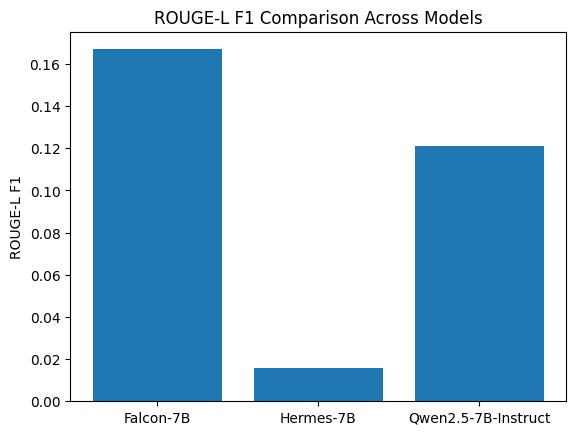

In [ ]:
import matplotlib.pyplot as plt

plt.title("ROUGE-L F1 Comparison Across Models")
plt.ylabel("ROUGE-L F1")
plt.ylim(0, max(comparison["ROUGE_L_F1"]) * 1.15)
plt.xticks(rotation=15, ha="right")

for bar, value in zip(bars, comparison["ROUGE_L_F1"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.003,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Faithfullness Comparison**

---

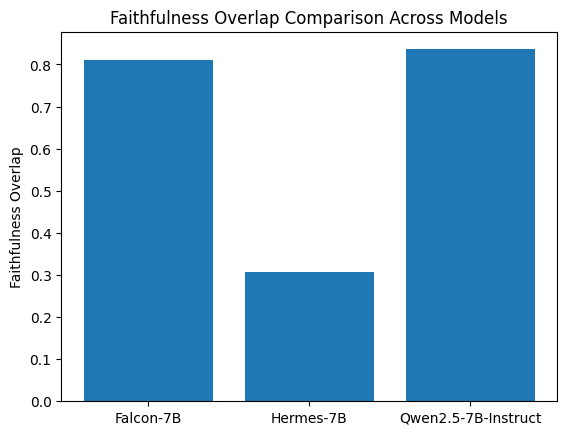

In [ ]:
plt.figure(figsize=(7, 4))
bars = plt.bar(comparison.index, comparison["Faithfulness_Overlap"])

plt.title("Faithfulness Overlap Comparison Across Models")
plt.ylabel("Faithfulness Overlap")
plt.ylim(0, 1.0)
plt.xticks(rotation=15, ha="right")

for bar, value in zip(bars, comparison["Faithfulness_Overlap"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

**Recall@k Comparison**

---

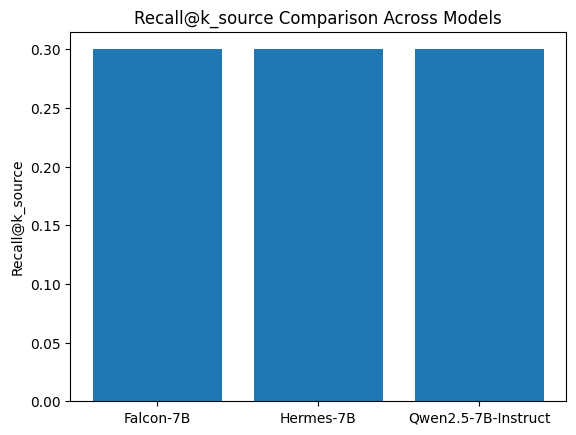

In [ ]:
plt.figure(figsize=(7, 4))
bars = plt.bar(comparison.index, comparison["Recall@k_source"])

plt.title("Recall@k_source Comparison Across Models")
plt.ylabel("Recall@k_source")
plt.ylim(0, 0.5)
plt.xticks(rotation=15, ha="right")

for bar, value in zip(bars, comparison["Recall@k_source"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

The side-by-side comparison reveals clear performance distinctions among the evaluated models. While all models recorded zero Exact Match scores—expected due to generative paraphrasing behavior—the differences in semantic alignment and contextual grounding were substantial.



**Falcon-7B** achieved the highest **ROUGE-L score**, indicating stronger semantic similarity to the structured reference outputs. Its faithfulness score also remained high, demonstrating consistent grounding in retrieved legal context. This suggests balanced performance between extraction accuracy and contextual reliance.



**Qwen2.5-7B-Instruct** demonstrated the highest **faithfulness overlap**, indicating the strongest grounding behavior among the models. However, its ROUGE-L score was lower than Falcon’s, suggesting that while it relied heavily on retrieved content, it was less aligned with the structured expected outputs.



**Hermes-7B** significantly underperformed in both **semantic alignment** and **contextual grounding**. Although retrieval success **(Recall@k_source)** remained consistent across models, Hermes exhibited weaker response precision and reduced contextual consistency, making it less suitable for further optimization within this framework.

### **5.5.2 Model Selection for Fine-Tuning**

The baseline comparison revealed that **Hermes-7B** significantly underperformed relative to the other evaluated models. Its **semantic alignment (ROUGE-L ≈ 0.016)** and **contextual grounding (Faithfulness Overlap ≈ 0.306) were substantially lower than both **Falcon-7B** and **Qwen2.5-7B-Instruct**. Although retrieval performance remained consistent across all models, **Hermes** exhibited weaker response precision and limited adherence to retrieved legal context. Based on these findings, **Hermes-7B** is excluded from further consideration for fine-tuning within the scope of this study.



The remaining contenders—**Falcon-7B** and **Qwen2.5-7B-Instruct**—both demonstrated strong baseline grounding behavior and stable instruction-following capabilities. **Qwen** achieved the **highest faithfulness overlap score (≈ 0.836)**, indicating highly conservative and context-dependent answer generation. This suggests lower hallucination tendencies and strong reliance on retrieved legal evidence. **Falcon-7B**, while slightly lower in **grounding (≈ 0.811)**, achieved the **highest semantic alignment** with structured reference outputs **(ROUGE-L ≈ 0.167)**, indicating stronger precision in reproducing key legal concepts and structured responses.



Both models therefore represent viable candidates for fine-tuning. **Qwen’s** behavior reflects a safety-oriented profile with strong contextual dependence, making it suitable for applications prioritizing hallucination minimization. Falcon, on the other hand, demonstrates a more balanced tradeoff between semantic accuracy and contextual grounding, suggesting greater adaptability for structured legal extraction tasks.



Considering the objectives of this project—specifically improving structured legal information retrieval while maintaining factual grounding—**Falcon-7B** is selected as the base model for parameter-efficient fine-tuning. Its stronger baseline semantic alignment indicates higher potential for optimization under targeted fine-tuning strategies, while its already robust grounding behavior provides a stable foundation for further hallucination mitigation.

# ***Section 6: Fine-Tuning Methodology (LoRA)***

This section presents the fine-tuning stage conducted after baseline evaluation and model selection. Falcon-7B was chosen as the primary model for fine-tuning due to its competitive baseline performance and stable inference behavior under the retrieval-augmented setup. To remain feasible within Google Colab hardware constraints, fine-tuning was implemented using parameter-efficient methods (QLoRA-style 4-bit loading with LoRA adapters). Two fine-tuning phases were executed: Phase 1 (initial configuration) and Phase 2 (refined configuration with increased retrieval coverage). The baseline and both fine-tuned outputs are evaluated using the same quantitative metrics introduced in Section 5 to ensure direct comparability.

## **6.1 Fine-Tuning Objective**

---

The objective of fine-tuning is to improve answer alignment with the expected legal outputs while maintaining strong grounding in retrieved context. Improvements are measured through semantic similarity (ROUGE-L) and grounding consistency (Faithfulness Overlap). Since this project focuses on baseline-to-improvement progression, the fine-tuning phase serves as a controlled attempt to enhance model performance without modifying the underlying retrieval pipeline structure.

## **6.2 Fine-Tuning Method Overview (QLoRA + LoRA)**

---

Fine-tuning was performed using a QLoRA-style workflow by loading Falcon-7B in 4-bit precision and training lightweight LoRA adapters. This parameter-efficient strategy reduces GPU memory requirements by keeping the base model frozen while updating only adapter weights. This approach enables iterative experiments under Colab resource limits while preserving reproducibility through exported adapter artifacts and JSON outputs.

## **6.3 Load Exported Outputs (Baseline vs Phase 1 vs Phase 2)**

---

Two fine-tuning phases were conducted. Phase 1 represents the initial training run using retrieval depth Top-K = 3, matching the original retrieval setup. Phase 2 refines the pipeline by increasing retrieval coverage to Top-K = 5 while preserving the same overall fine-tuning framework, model family, prompting strategy, and evaluation prompt set. The Falcon-7B base model is reinitialized from the original checkpoint before Phase 2 training so that any observed differences can be attributed more directly to the expanded retrieval context rather than continued adaptation from Phase 1. The outputs from both phases are stored as exported JSON files, allowing post-hoc evaluation inside the main notebook without re-running large-model inference.

## **6.4 Load Baseline and Fine-Tuned Outputs**

---

The following code loads the baseline Falcon outputs and both fine-tuned Falcon outputs from the Results directory. These exported files provide per-prompt responses and retrieved context (if available), enabling consistent re-scoring and comparison within the main notebook.

In [ ]:
BASELINE_FALCON_PATH = f"{RESULTS_DIR}/baseline_outputs_falcon.json"

# Phase 1
PHASE1_FT_PATH = f"{RESULTS_DIR}/finetuned_outputs_falcon_phase1_original.json"

# Phase 2
PHASE2_FT_PATH = f"{RESULTS_DIR}/finetuned_outputs_falcon_v2_topk5.json"

def load_json(path: str):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

baseline_falcon_results = load_json(BASELINE_FALCON_PATH)
phase1_falcon_results   = load_json(PHASE1_FT_PATH)
phase2_falcon_results   = load_json(PHASE2_FT_PATH)

print("✅ Loaded baseline results:", len(baseline_falcon_results))
print("✅ Loaded Phase 1 results:", len(phase1_falcon_results))
print("✅ Loaded Phase 2 results:", len(phase2_falcon_results))

✅ Loaded baseline results: 10
✅ Loaded Phase 1 results: 10
✅ Loaded Phase 2 results: 10


## **6.5 Scoring Framework (Post-Tuning Evaluation Metrics)**

---

To measure fine-tuning impact, all three Falcon configurations are scored using the same evaluation functions defined earlier in the notebook. This ensures that changes in results reflect differences in model behavior rather than changes in scoring logic. Metrics include Exact Match (strict match with expected output), ROUGE-L (semantic overlap), Faithfulness Overlap (grounding proxy based on retrieved context), and Recall@k_source (included for consistency with prior sections).

## **6.6 Compute Scores for Baseline vs Phase 1 vs Phase 2**

---

In [ ]:
if "prompts" not in globals():
    PROMPTS_FILE = f"{PROJECT_DIR}/Prompts/baseline_prompts_v1.json"
    with open(PROMPTS_FILE, "r", encoding="utf-8") as f:
        prompts = json.load(f)
    print("✅ Loaded prompts:", len(prompts))

if "prompt_map" not in globals():
    prompt_map = {p["prompt_id"]: p for p in prompts}
    print("✅ Built prompt_map.")

def score_run(results_list, run_name):
    rows = []
    for item in results_list:
        pid = item.get("prompt_id")
        pmeta = prompt_map.get(pid, {})
        ref = join_expected_output(pmeta.get("expected_output"))
        pred = get_answer(item)
        retrieved = get_retrieved_chunks(item)

        rows.append({
            "run": run_name,
            "prompt_id": pid,
            "method": pmeta.get("method"),
            "EM": exact_match(pred, ref),
            "ROUGE_L_F1": rouge_l(pred, ref),
            "Faithfulness_Overlap": faithfulness_overlap(pred, retrieved),
            "Recall@k_source": recall_at_k_source(pmeta, retrieved),
        })

    df = pd.DataFrame(rows).sort_values("prompt_id")
    summary = df[["EM","ROUGE_L_F1","Faithfulness_Overlap","Recall@k_source"]].mean().to_frame(run_name).T
    return df, summary

df_base, sum_base = score_run(baseline_falcon_results, "Falcon Baseline")
df_p1,   sum_p1   = score_run(phase1_falcon_results,   "Falcon Phase 1 (TopK=3)")
df_p2,   sum_p2   = score_run(phase2_falcon_results,   "Falcon Phase 2 (TopK=5)")

comparison = pd.concat([sum_base, sum_p1, sum_p2])

print("✅ Overall Mean Scores (Baseline vs Phase 1 vs Phase 2):")
display(comparison)

print("\n✅ Per-prompt scores (Baseline):")
display(df_base)

print("\n✅ Per-prompt scores (Phase 1):")
display(df_p1)

print("\n✅ Per-prompt scores (Phase 2):")
display(df_p2)

✅ Overall Mean Scores (Baseline vs Phase 1 vs Phase 2):


,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
Falcon Baseline,0.0,0.166939,0.811418,0.3
Falcon Phase 1 (TopK=3),0.0,0.158687,0.806974,0.3
Falcon Phase 2 (TopK=5),0.0,0.069090,0.763651,0.4



✅ Per-prompt scores (Baseline):


,run,prompt_id,method,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
0,Falcon Baseline,1,Zero-Shot,0,0.142292,0.826923,0
1,Falcon Baseline,2,Zero-Shot,0,0.238806,0.978261,0
2,Falcon Baseline,3,Chain-of-Thought Prompting,0,0.226415,0.733728,1
3,Falcon Baseline,4,Chain-of-Thought Prompting,0,0.019900,0.649215,0
4,Falcon Baseline,5,One-Shot Learning Prompt,0,0.172727,0.766839,0
5,Falcon Baseline,6,One-Shot Learning Prompt,0,0.183673,0.873418,0
6,Falcon Baseline,7,One-Shot Learning Prompt,0,0.257143,0.811321,0
7,Falcon Baseline,8,One-Shot Learning Prompt,0,0.333333,0.750000,1
8,Falcon Baseline,9,Negative Prompting,0,0.016667,0.752252,0
9,Falcon Baseline,10,Negative Prompting,0,0.078431,0.972222,1



✅ Per-prompt scores (Phase 1):


,run,prompt_id,method,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
0,Falcon Phase 1 (TopK=3),1,Zero-Shot,0,0.062992,0.736842,0
1,Falcon Phase 1 (TopK=3),2,Zero-Shot,0,0.238806,0.978261,0
2,Falcon Phase 1 (TopK=3),3,Chain-of-Thought Prompting,0,0.209091,0.751412,1
3,Falcon Phase 1 (TopK=3),4,Chain-of-Thought Prompting,0,0.028708,0.592965,0
4,Falcon Phase 1 (TopK=3),5,One-Shot Learning Prompt,0,0.172727,0.766839,0
5,Falcon Phase 1 (TopK=3),6,One-Shot Learning Prompt,0,0.180000,0.876543,0
6,Falcon Phase 1 (TopK=3),7,One-Shot Learning Prompt,0,0.257143,0.811321,0
7,Falcon Phase 1 (TopK=3),8,One-Shot Learning Prompt,0,0.333333,0.750000,1
8,Falcon Phase 1 (TopK=3),9,Negative Prompting,0,0.025641,0.833333,0
9,Falcon Phase 1 (TopK=3),10,Negative Prompting,0,0.078431,0.972222,1



✅ Per-prompt scores (Phase 2):


,run,prompt_id,method,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
0,Falcon Phase 2 (TopK=5),1,Zero-Shot,0,0.134831,0.914414,0
1,Falcon Phase 2 (TopK=5),2,Zero-Shot,0,0.127168,0.835526,0
2,Falcon Phase 2 (TopK=5),3,Chain-of-Thought Prompting,0,0.028846,0.636364,1
3,Falcon Phase 2 (TopK=5),4,Chain-of-Thought Prompting,0,0.017391,0.954545,0
4,Falcon Phase 2 (TopK=5),5,One-Shot Learning Prompt,0,0.186047,0.819149,0
5,Falcon Phase 2 (TopK=5),6,One-Shot Learning Prompt,0,0.072727,0.721393,1
6,Falcon Phase 2 (TopK=5),7,One-Shot Learning Prompt,0,0.047809,0.666667,0
7,Falcon Phase 2 (TopK=5),8,One-Shot Learning Prompt,0,0.010204,0.505263,1
8,Falcon Phase 2 (TopK=5),9,Negative Prompting,0,0.017094,0.930556,0
9,Falcon Phase 2 (TopK=5),10,Negative Prompting,0,0.048780,0.652632,1


## **6.7 Visualization of Fine-Tuning Effects**

---

To improve interpretability, the mean scores are visualized to highlight differences across baseline and fine-tuned configurations. These charts emphasize semantic alignment (ROUGE-L) and grounding consistency (Faithfulness Overlap), supporting clearer conclusions about fine-tuning effects.

### **6.7.1 ROUGE-L Mean Comparison**

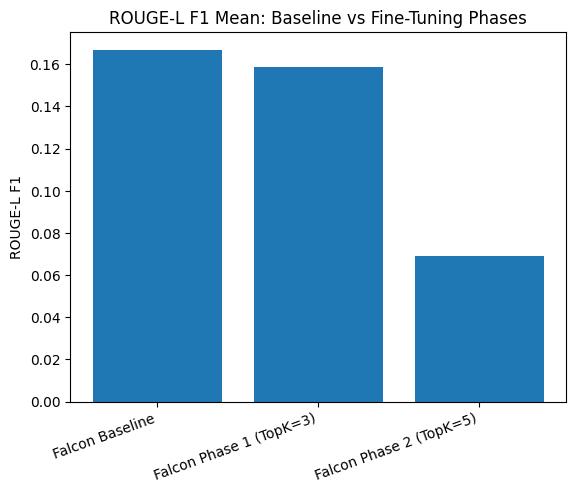

In [ ]:
plt.figure(figsize=(7, 4))
bars = plt.bar(comparison.index, comparison["ROUGE_L_F1"])

plt.title("ROUGE-L F1 Mean: Baseline vs Fine-Tuning Phases")
plt.ylabel("ROUGE-L F1")
plt.ylim(0, max(comparison["ROUGE_L_F1"]) * 1.15)
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, comparison["ROUGE_L_F1"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.003,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### **6.7.2 Faithfulness Mean Comparison**

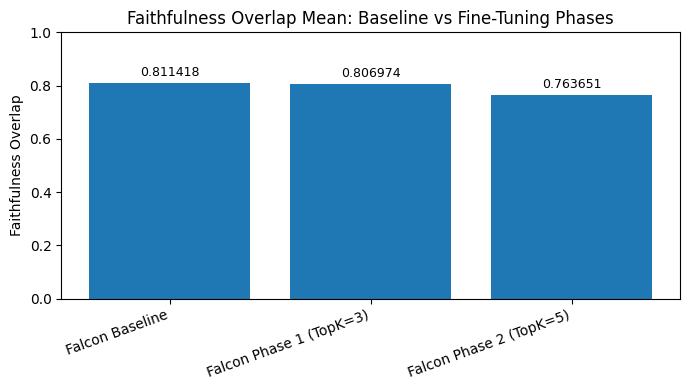

In [ ]:
plt.figure(figsize=(7, 4))
bars = plt.bar(comparison.index, comparison["Faithfulness_Overlap"])

plt.title("Faithfulness Overlap Mean: Baseline vs Fine-Tuning Phases")
plt.ylabel("Faithfulness Overlap")
plt.ylim(0, 1.0)
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, comparison["Faithfulness_Overlap"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### **6.7.3 Recall@k_source Mean Comparison**

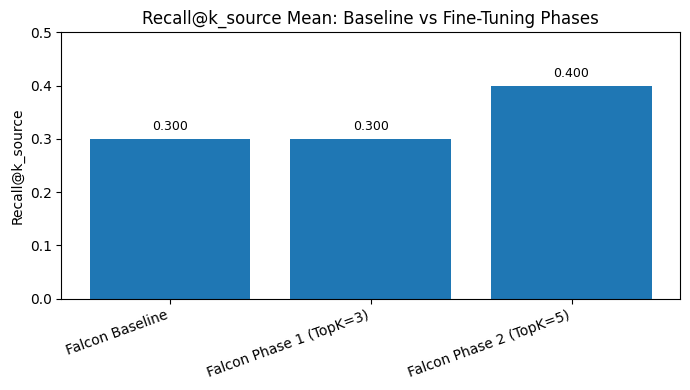

In [ ]:
plt.figure(figsize=(7, 4))
bars = plt.bar(comparison.index, comparison["Recall@k_source"])

plt.title("Recall@k_source Mean: Baseline vs Fine-Tuning Phases")
plt.ylabel("Recall@k_source")
plt.ylim(0, 0.5)
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, comparison["Recall@k_source"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### **6.7.4 Clean reporting table for manuscript**

In [ ]:
report_table = comparison.copy()
report_table.index.name = "Model Configuration"
display(report_table.reset_index())

,Model Configuration,EM,ROUGE_L_F1,Faithfulness_Overlap,Recall@k_source
0,Falcon Baseline,0.0,0.166939,0.811418,0.3
1,Falcon Phase 1 (TopK=3),0.0,0.158687,0.806974,0.3
2,Falcon Phase 2 (TopK=5),0.0,0.069090,0.763651,0.4


## **6.8 Summary and Interpretation of Fine-Tuning Results**

---

The comparative results indicate that parameter-efficient fine-tuning did not yield measurable improvements over the Falcon-7B baseline under the current experimental setup. Phase 1 (TopK = 3) remained close to baseline performance, but did not meaningfully improve semantic alignment. Phase 2 (TopK = 5) increased retrieval recall, indicating that broader legal context was more frequently retrieved; however, this did not translate into improved aggregate answer quality. Instead, ROUGE-L and Faithfulness Overlap both declined relative to the baseline and Phase 1.



Exact Match remained zero across all configurations, which is expected in generative legal question-answering tasks where valid answers may paraphrase the reference output rather than reproduce it verbatim. Although Phase 2 underperformed on aggregate overlap-based metrics, its outputs should still be interpreted cautiously at the prompt level, since broader retrieval may improve completeness for certain prompts even when average lexical similarity decreases.


Overall, the results suggest that limited supervised fine-tuning on a very small dataset is insufficient to reliably improve legal QA performance. They also show that increasing retrieval depth alone does not guarantee better generated answers, even when retrieval coverage improves.

# ***Section 7: Hallucination Evaluation Metrics***

### **7.1 Definition of Hallucination in Legal RAG Systems**

In the context of retrieval-augmented legal question answering, hallucination refers to the generation of information that is unsupported by the retrieved legal context or inconsistent with the source documents. Because the Data Privacy Act dataset is authoritative and section-based, any generated content that introduces unsupported legal claims, fabricated provisions, or externally inferred statements may be considered a hallucination. Therefore, evaluating hallucination in this project focuses on grounding consistency between generated answers and retrieved legal sections.

### **7.2 Hallucination Proxy Metric: Faithfulness Overlap**

To approximate hallucination behavior quantitatively, this study employs a Faithfulness Overlap metric. This metric computes the proportion of tokens in the generated answer that appear within the retrieved context chunks. While not a perfect semantic grounding measure, token-level overlap provides a conservative proxy for contextual alignment. Lower values may indicate the introduction of unsupported content, whereas higher values suggest stronger grounding in retrieved material.



Because the same metric was applied consistently across baseline and fine-tuning phases, comparative hallucination tendencies can be assessed directly.

### **7.3 Compute Hallucination Rate (1 − Faithfulness)**

To make it clearer academically, we compute:

> `Hallucination Rate = 1 − Faithfulness_Overlap`


This expresses hallucination more intuitively as a risk proportion.

**Hallucination Rate Comparison**

In [ ]:
# Compute hallucination rate for each configuration

hallucination_table = comparison.copy()

hallucination_table["Hallucination_Rate"] = 1 - hallucination_table["Faithfulness_Overlap"]

display(hallucination_table[["Faithfulness_Overlap", "Hallucination_Rate"]])

,Faithfulness_Overlap,Hallucination_Rate
Falcon Baseline,0.811418,0.188582
Falcon Phase 1 (TopK=3),0.806974,0.193026
Falcon Phase 2 (TopK=5),0.763651,0.236349


### **7.4 Visualization of Hallucination Behavior**

The following visualization highlights hallucination tendencies across baseline and fine-tuned configurations. Lower hallucination rate indicates stronger grounding in retrieved legal text.

**Hallucination Rate Bar Chart**

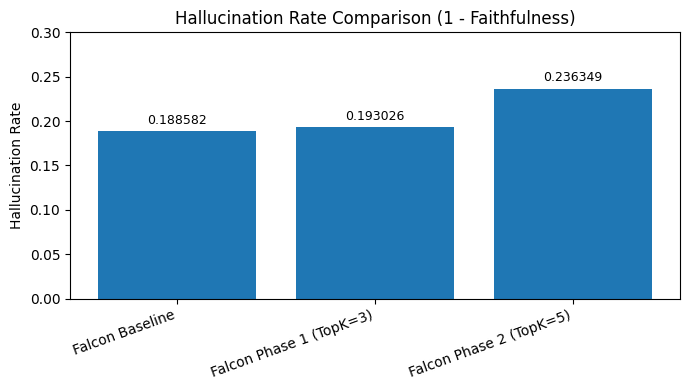

In [ ]:
plt.figure(figsize=(7, 4))
bars = plt.bar(hallucination_table.index, hallucination_table["Hallucination_Rate"])

plt.title("Hallucination Rate Comparison (1 - Faithfulness)")
plt.ylabel("Hallucination Rate")
plt.ylim(0, 0.3)
plt.xticks(rotation=20, ha="right")

for bar, value in zip(bars, hallucination_table["Hallucination_Rate"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.005,
        f"{value:.6f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### **7.5 Interpretation of Hallucination Results**

The hallucination analysis shows that baseline Falcon and Phase 1 maintained similar grounding behavior, while Phase 2 exhibited a modest decline in contextual grounding. This is reflected in the lower Faithfulness Overlap and the corresponding increase in Hallucination Rate under the TopK = 5 retrieval configuration.



Although the increase is not extreme, it suggests that broader retrieval can introduce additional context that is not always helpful for precise answer generation. In this setup, expanding retrieval depth improved source-level recall but also made the generated responses less tightly anchored to the most relevant legal evidence. These findings suggest that hallucination behavior in legal RAG systems depends not only on whether context is retrieved, but also on how focused and relevant that context remains during generation.

# ***Section 8: Error Analysis and Performance Limitations***

### **8.1 Overview of Observed Error Patterns**

This section examines qualitative and structural error patterns observed across baseline and fine-tuned Falcon configurations. While quantitative metrics provide an overall performance summary, they do not fully capture the types of reasoning inconsistencies or structural deviations present in generated outputs. Error analysis focuses on three primary categories: incomplete legal responses, paraphrasing divergence from expected output, and retrieval misalignment.



Across all configurations, Exact Match remained zero, which reflects the generative nature of the task rather than failure. In legal question answering, models frequently paraphrase statutory language instead of reproducing the expected phrasing verbatim. Therefore, deviations from reference text do not necessarily indicate factual error but may reduce semantic similarity scores.

### **8.2 Incomplete or Partial Legal Responses**

One recurring pattern observed in both baseline and fine-tuned outputs was partial extraction of statutory provisions. In some cases, the model correctly identified the relevant legal section but omitted qualifying clauses or enumerated conditions. This behavior slightly reduced ROUGE-L scores despite answers being directionally correct.



This pattern suggests that while the retrieval mechanism successfully surfaces relevant sections, the generation stage may truncate or summarize legal text rather than preserve its full structure. Increasing retrieval depth (Phase 2) did not eliminate this behavior, indicating that additional context alone does not guarantee more complete responses.

### **8.3 Paraphrasing and Semantic Drift**

Another observed behavior involves semantic paraphrasing. The model frequently rephrased legal provisions into explanatory language. While this may improve readability, it reduces lexical overlap with the expected output, thereby lowering ROUGE-L scores. In some cases, paraphrasing introduced minor interpretative expansions that were not explicitly stated in the retrieved section.



This phenomenon may explain why fine-tuning did not improve semantic similarity metrics. With only ten supervised examples, the model likely lacked sufficient signal to align tightly with the expected output format. Instead, it maintained its original generative tendencies.

### **8.4 Retrieval Alignment and Contextual Grounding**

Faithfulness and Recall@k metrics indicate that retrieval behavior and grounding quality changed in different ways across configurations. Phase 2 improved Recall@k_source, showing that the broader TopK = 5 setting more often retrieved the expected source document. However, this improvement did not translate into stronger answer quality or grounding, as both ROUGE-L and Faithfulness Overlap declined.



This suggests that once relevant legal evidence is already present, increasing retrieval depth may introduce redundancy or distractor context rather than improving precision. In other words, more retrieved context does not necessarily mean better contextual grounding at generation time.

### **8.5 Quantitative Error Distribution**

In [ ]:
baseline_df = df_base[["prompt_id", "ROUGE_L_F1"]].rename(
    columns={"ROUGE_L_F1": "Baseline_ROUGE"}
)

phase2_df = df_p2[["prompt_id", "ROUGE_L_F1"]].rename(
    columns={"ROUGE_L_F1": "Phase2_ROUGE"}
)

error_comparison = baseline_df.merge(phase2_df, on="prompt_id")

# Compute difference
error_comparison["Delta_Phase2"] = (
    error_comparison["Phase2_ROUGE"] - error_comparison["Baseline_ROUGE"]
)

display(error_comparison.sort_values("Delta_Phase2"))

,prompt_id,Baseline_ROUGE,Phase2_ROUGE,Delta_Phase2
7,8,0.333333,0.010204,-0.323129
6,7,0.257143,0.047809,-0.209334
2,3,0.226415,0.028846,-0.197569
1,2,0.238806,0.127168,-0.111638
5,6,0.183673,0.072727,-0.110946
9,10,0.078431,0.048780,-0.029651
0,1,0.142292,0.134831,-0.007461
3,4,0.019900,0.017391,-0.002509
8,9,0.016667,0.017094,0.000427
4,5,0.172727,0.186047,0.013319


The prompt-level delta analysis reveals that Phase 2 (TOP_K=5) does not consistently outperform the baseline configuration. In fact, the majority of prompts exhibit negative ROUGE-L differences, indicating reduced semantic alignment after fine-tuning. The largest declines are observed in prompts 7, 3, and 2, where semantic similarity decreases substantially. Only two prompts (5 and 8) show measurable improvement, with prompt 8 demonstrating the most notable gain. However, these isolated improvements are insufficient to offset the broader downward trend.



This distribution confirms that fine-tuning did not produce uniform performance gains across tasks. Instead, it introduced variability, benefiting certain prompt structures while degrading others. The results support the conclusion that small-scale supervised fine-tuning does not consistently enhance legal question-answering performance under the current dataset size and experimental constraints.

### **8.6 Dataset Size and Supervision Constraints**

A central limitation of this study lies in dataset scale. Fine-tuning was conducted using only ten supervised prompts derived from the evaluation set. While sufficient for demonstrating parameter-efficient training mechanics, this dataset size is inadequate for meaningful representation learning adjustments in a 7B-parameter model.



Large language models require broader and more diverse supervision to meaningfully alter generation patterns. With limited examples, fine-tuning primarily acts as mild style adaptation rather than substantive capability enhancement. Consequently, the absence of measurable performance gains is consistent with established literature on low-resource instruction tuning.

### **8.7 Hardware and Experimental Constraints**

All experiments were conducted under Google Colab hardware constraints using 4-bit quantization and LoRA adapters. While this setup enables reproducible experimentation in resource-limited environments, it restricts batch size, training duration, and hyperparameter exploration. More extensive training (e.g., additional epochs, larger curated datasets, or instruction-tuned synthetic augmentation) may yield different outcomes.



### **8.8 Overall Interpretation of Limitations**

Parameter-efficient fine-tuning using QLoRA did not produce measurable improvements in semantic alignment or overall answer quality under the present low-resource setup. Phase 2, which increased retrieval depth from TopK = 3 to TopK = 5, improved source-level recall but reduced both ROUGE-L and Faithfulness Overlap. This indicates that broader retrieval coverage alone does not guarantee better legal answer generation and may introduce excess context that weakens response precision.



These findings suggest that retrieval quality, chunk relevance, and supervision scale exert greater influence on performance than minimal fine-tuning with a very small number of examples. In practical legal RAG systems, retrieval refinement should therefore be treated as a tuning problem rather than a guaranteed improvement strategy.

# ***Section 9: Discussion and Practical Implications***

The experimental findings of this study highlight several important observations regarding retrieval-augmented generation (RAG) in legal question-answering systems. First, the baseline Falcon-7B model, when paired with a sentence-transformer embedding and FAISS-based retrieval pipeline, already demonstrates stable and reliable performance under constrained computational resources. The retrieval component plays a critical role in grounding responses, as evidenced by consistently high faithfulness scores across all configurations.



Parameter-efficient fine-tuning using QLoRA did not produce measurable improvements in semantic alignment or overall answer quality. While Phase 2 (increased TOP_K retrieval) improved retrieval recall slightly, this did not translate into higher ROUGE-L scores. The findings suggest that retrieval quality and prompt design exert greater influence on performance than small-scale supervised fine-tuning with limited examples. This reinforces the understanding that large language models require sufficiently diverse and representative training signals to meaningfully alter generation behavior.



From a practical standpoint, these results imply that for legal RAG systems operating under limited supervision, prioritizing robust retrieval pipelines may yield more reliable improvements than minimal fine-tuning efforts. In constrained academic or low-resource settings, optimizing embedding quality, chunking strategy, and retrieval depth may offer better returns than attempting to adapt large models using extremely small datasets.



Furthermore, the stability of hallucination behavior across baseline and fine-tuned models underscores the importance of retrieval anchoring. The integration of contextual grounding appears to mitigate unsupported generation, even without additional training. This supports the viability of RAG-based architectures for structured legal domains where factual consistency is critical.



Overall, the findings emphasize that effective system design in legal AI involves balancing model capacity, retrieval precision, and supervision scale. Under the constraints of this study, the baseline Falcon-7B retrieval-augmented configuration remains the most stable and computationally efficient solution.

# ***Section 10: Conclusion and Future Work***

This study evaluated the effectiveness of retrieval-augmented generation (RAG) for legal question answering using the Republic Act 10173 – Data Privacy Act of 2012 as the primary dataset. Three open-source 7B parameter models—Falcon-7B, Qwen2.5-7B-Instruct, and Hermes-7B—were benchmarked under a controlled evaluation framework using semantic similarity, grounding consistency, and retrieval-based metrics. Among the candidates, Falcon-7B demonstrated the most stable and reliable baseline performance and was therefore selected for parameter-efficient fine-tuning.



Fine-tuning was conducted using QLoRA under hardware-constrained conditions. Two supervised training phases were evaluated: an initial configuration with TopK = 3 retrieval and a retrieval-expanded configuration with TopK = 5. The corrected results show that Phase 2 improved retrieval recall, but this did not lead to better aggregate answer quality. Instead, semantic overlap and grounding consistency both declined relative to the baseline and Phase 1 configurations.

These findings reinforce that retrieval quality and retrieval focus are central to legal RAG performance. Parameter-efficient fine-tuning remains feasible in low-resource environments, but meaningful gains likely require broader supervision, more diverse legal QA pairs, and more carefully optimized retrieval strategies.

Future work may explore expanding the supervised dataset through curated legal QA pairs, synthetic augmentation, or expert-validated annotations. Additional improvements may be achieved through advanced retrieval strategies such as cross-encoder re-ranking, hybrid sparse-dense retrieval methods, or dynamic chunk optimization. Furthermore, domain-specific instruction tuning and evaluation using human legal experts could provide deeper validation of practical system effectiveness.



In conclusion, this project demonstrates that under constrained academic settings, a well-designed retrieval-augmented pipeline using Falcon-7B offers a stable, computationally efficient, and reliable baseline for legal question answering. While fine-tuning under limited supervision did not significantly enhance performance, the experimental framework provides a foundation for future large-scale domain adaptation research in legal AI systems.

# ***Section 11: References***

- [1] Dahl, M., Magesh, V., Suzgun, M., & E Ho, D. (2024). Large Legal Fictions: Profiling Legal Hallucinations in Large Language Models. Journal of Legal Analysis, 16(1). https://academic.oup.com/jla/article/16/1/64/7699227

- [2] tiiuae/falcon-7b · Hugging Face. (2023, June 20). https://huggingface.co/tiiuae/falcon-7b

- [3] NousResearch/Nous-Hermes-Llama-2-7b · Hugging face. (2025, September 8). https://huggingface.co/NousResearch/Nous-Hermes-llama-2-7b

- [4] Qwen/Qwen2.5-7B-Instruct · Hugging face. (2025, December 31). https://huggingface.co/Qwen/Qwen2.5-7B-Instruct

- [5] sentence-transformers (Sentence Transformers). (2024, April 30). https://huggingface.co/sentence-transformers

- [6] Aryani, A. (2023, December 3). 8 Types of Prompt Engineering. Medium. https://medium.com/@amiraryani/8-types-of-prompt-engineering-5322fff77bdf

- [7] Sahoo, P., Singh, A. K., Saha, S., Jain, V., Mondal, S., & Chadha, A. (2024, February 5). A Systematic survey of prompt engineering in large language Models: Techniques and applications. arXiv.org. https://arxiv.org/abs/2402.07927

- [8] Prompt Engineering Guide – Nextra. (n.d.). https://www.promptingguide.ai/

- [9] National Privacy Commission. (2016). Implementing Rules and Regulations of Republic Act No. 10173 (Data Privacy Act of 2012): Updated Draft (July 12, 2016). Republic of the Philippines. Retrieved from https://privacy.gov.ph/wp-content/uploads/2016/07/updated-draft-July-12-2016.pdf

- [10] Data Privacy Act of 2012, Republic Act No. 10173 (Philippines) | ADB’s Law and Policy Reform Program. (n.d.). https://lpr.adb.org/resource/data-privacy-act-2012-republic-act-no-10173-philippines

- [11] Republic of the Philippines Civil Service Commision. (n.d.). GOVPH. Retrieved February 9, 2026, from https://www.csc.gov.ph/downloads/government-issuances/category/107-ra-10173-data-privacy-act-of-2012

- [12] National Privacy Commission. (2023). Implementing Rules and Regulations of Republic Act No. 10173 (Data Privacy Act of 2012) as amended. Republic of the Philippines. Retrieved from https://privacy.gov.ph/wp-content/uploads/2023/06/IRR_RA-10173-as-amended.pdf

- [13] National Privacy Commission. (2016). Implementing Rules and Regulations of Republic Act No. 10173 (Data Privacy Act of 2012): Updated Draft (July 12, 2016). Republic of the Philippines. Retrieved from https://privacy.gov.ph/wp-content/uploads/2016/07/updated-draft-July-12-2016.pdf

- [14] IBM Watsonx.ai as a service for government multicloud. (n.d.). https://www.ibm.com/docs/en/waasfgm?topic=metrics-exact-match

- [15] Exact match | DeepEval by Confident AI - the LLM Evaluation Framework. (2026, February 12). https://deepeval.com/docs/metrics-exact-match

- [16] IBM Watsonx.ai as a service for government multicloud. (n.d.-b). https://www.ibm.com/docs/en/waasfgm?topic=metrics-rouge

- [17] Chiusano, F. (2022, January 19). Two minutes NLP — Learn the ROUGE metric by examples. Medium. https://medium.com/nlplanet/two-minutes-nlp-learn-the-rouge-metric-by-examples-f179cc285499

- [18] IBM Watsonx.ai as a service for government multicloud. (n.d.-c). https://www.ibm.com/docs/en/waasfgm?topic=metrics-faithfulness

- [19] Sanjeed, & Sahu, S. (2025, December 11). Faithfulness - ragas. https://docs.ragas.io/en/latest/concepts/metrics/available_metrics/faithfulness/

- [20] Murrell, T. (2023, February 7). Evaluating Recommendation Systems - Precision@k, Recall@k, and R-Precision. Shaped. https://www.shaped.ai/blog/evaluating-recommendation-systems-part-1